<a href="https://colab.research.google.com/github/turnleftorgo/Deep_learning/blob/main/Reinforcement_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import random
import copy
import torch
from collections import deque

In [ ]:
class Environment:

    def __init__(self, width=5, length=5, reward_B= 150):
        self.width = width
        self.length = length

        self.agent_locations = [(random.randint(0, self.length - 1), random.randint(0, self.width - 1)) for _ in range(4)]
        self.B_location = (random.randint(0, self.length - 1), random.randint(0, self.width - 1))
        self.agent_has_full_secret = [False, False, False, False]


        self.movement_reward = -5 # Sport

        self.meet_reward = 20      # Secret
        self.B_Reward = reward_B  # destination



        while len(set(self.agent_locations)) < 4 or self.B_location in self.agent_locations:
            self.agent_locations = [(random.randint(0, self.length - 1), random.randint(0, self.width - 1)) for _ in range(4)]
            self.B_location = (random.randint(0, self.length - 1), random.randint(0, self.width - 1))

    def reset_state(self):
        self.agent_locations = [(random.randint(0, self.length - 1), random.randint(0, self.width - 1)) for _ in range(4)]
        self.B_location = (random.randint(0, self.length - 1), random.randint(0, self.width - 1))
        self.agent_has_full_secret = [False, False, False, False]

        while len(set(self.agent_locations)) < 4 or self.B_location in self.agent_locations:
            self.agent_locations = [(random.randint(0, self.length - 1), random.randint(0, self.width - 1)) for _ in range(4)]
            self.B_location = (random.randint(0, self.length - 1), random.randint(0, self.width - 1))

        return self.agent_locations, self.B_location, self.agent_has_full_secret

    def step(self, agent_idx, action):
        current_pos = self.agent_locations[agent_idx]
        movement_reward = self.movement_reward


        if action == 0:  # South
            if current_pos[0] > 0:
                self.agent_locations[agent_idx] = (current_pos[0] - 1, current_pos[1])
            else:
                self.agent_locations[agent_idx] = (current_pos[0] + 1, current_pos[1])
        elif action == 1:  # North
            if current_pos[0] < self.length - 1:
                self.agent_locations[agent_idx] = (current_pos[0] + 1, current_pos[1])
            else:
                self.agent_locations[agent_idx] = (current_pos[0] - 1, current_pos[1])
        elif action == 2:  # East
            if current_pos[1] < self.width - 1:
                self.agent_locations[agent_idx] = (current_pos[0], current_pos[1] + 1)
            else:
                self.agent_locations[agent_idx] = (current_pos[0], current_pos[1] - 1)
        elif action == 3:  # West
            if current_pos[1] > 0:
                self.agent_locations[agent_idx] = (current_pos[0], current_pos[1] - 1)
            else:
                self.agent_locations[agent_idx] = (current_pos[0], current_pos[1] + 1)


        reward = movement_reward
        done = False

        type_1 = [0, 1]
        type_2 = [2, 3]

        if agent_idx in type_1 :

           for i in type_2 :
               if self.agent_locations[agent_idx] == self.agent_locations[i] and self.agent_locations[agent_idx] != self.B_location:
                  if not self.agent_has_full_secret[agent_idx] and not self.agent_has_full_secret[i]:
                        self.agent_has_full_secret[agent_idx] = True
                        self.agent_has_full_secret[i] = True
                        reward += self.meet_reward
                  elif not self.agent_has_full_secret[agent_idx]:
                        self.agent_has_full_secret[agent_idx] = True
                        reward += self.meet_reward
                  elif not self.agent_has_full_secret[i]:
                        self.agent_has_full_secret[i] = True

        if agent_idx in type_2 :

           for i in type_1 :
               if self.agent_locations[agent_idx] == self.agent_locations[i] and self.agent_locations[agent_idx] != self.B_location:
                  if not self.agent_has_full_secret[agent_idx] and not self.agent_has_full_secret[i]:
                        self.agent_has_full_secret[agent_idx] = True
                        self.agent_has_full_secret[i] = True
                        reward += self.meet_reward
                  elif not self.agent_has_full_secret[agent_idx]:
                        self.agent_has_full_secret[agent_idx] = True
                        reward += self.meet_reward
                  elif not self.agent_has_full_secret[i]:
                        self.agent_has_full_secret[i] = True


        if self.agent_locations[agent_idx] == self.B_location:
            if self.agent_has_full_secret[agent_idx]:
                reward += self.B_Reward
                done = True


        next_state = (self.agent_locations, self.B_location, self.agent_has_full_secret)
        return next_state, reward, done

In [ ]:
class Deep_q_learning_agent():

    def __init__(self, statespace_size=65, action_size=5, batch_size= 64 , gamma=0.9, epsilon=1.0,
                 epsilon_min=0.2, epsilon_decay=0.997, lr=1e-3, target_network_update_frequency= 100 ):

        self.statespace_size = statespace_size
        self.action_size = action_size
        self.batch_size = batch_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.lr = lr
        self.target_network_update_frequency = target_network_update_frequency


        self.experience_cache = deque(maxlen = 50000)



        self.model_type_1, self.target_model_type_1 = self.q_neural_network()  # Pair for Type 1 agents
        self.model_type_2, self.target_model_type_2 = self.q_neural_network()  # Pair for Type 2 agents


        self.optimizer_type_1 = torch.optim.Adam(self.model_type_1.parameters(), lr=self.lr) # Optimizers for type 1 training network
        self.optimizer_type_2 = torch.optim.Adam(self.model_type_2.parameters(), lr=self.lr)

        self.loss_fn = torch.nn.MSELoss()

    def q_neural_network(self):
        l1 = 76
        l2 = 128
        l3 = 64
        l4 = 4

        model_A = torch.nn.Sequential(
           torch.nn.Linear(l1, l2),
           torch.nn.ReLU(),
           torch.nn.Linear(l2, l3),
           torch.nn.ReLU(),
           torch.nn.Linear(l3, l4),
        )

        model_B = copy.deepcopy(model_A)

        return model_A, model_B

    def update_target(self, model_type):

        if model_type == 1:
            self.target_model_type_1.load_state_dict(self.model_type_1.state_dict())  # Update Type 1 target network

        elif model_type == 2:
            self.target_model_type_2.load_state_dict(self.model_type_2.state_dict())  # Update Type 2 target network

    def get_qvals(self, state, model_type):

        state_tensor = torch.from_numpy(state).float()

        if model_type == 1:
            qvals_torch = self.model_type_1(state_tensor)

        else:
            qvals_torch = self.model_type_2(state_tensor)

        return qvals_torch.data.numpy()                                      # get Q value from Perdiction Neural Network

    def get_qvals_target(self, state, model_type):

        state_tensor = torch.from_numpy(state).float()

        if model_type == 1:
            qvals_torch = self.target_model_type_1(state_tensor)

        else:
            qvals_torch = self.target_model_type_2(state_tensor)

        return qvals_torch.data.numpy()                                      # get Q value from Target Neural Network

    def train_one_step(self, states, actions, targets, model_type):

        state1_batch = torch.stack([torch.from_numpy(s).float() for s in states], dim=0)

        action_batch = torch.Tensor(actions)

        Q1 = self.model_type_1(state1_batch) if model_type == 1 else self.model_type_2(state1_batch)
        X = Q1.gather(dim=1, index=action_batch.long().unsqueeze(dim=1)).squeeze()
        Y = torch.tensor(targets, dtype=torch.float32)

        loss = self.loss_fn(X, Y)

        if model_type == 1:
            self.optimizer_type_1.zero_grad()
        else:
            self.optimizer_type_2.zero_grad()

        loss.backward()



        if model_type == 1:
            self.optimizer_type_1.step()
        else:
            self.optimizer_type_2.step()

        return loss.item()

In [ ]:
class Training:
    def __init__(self, agent, env, episodes=2000):

        self.agent = agent
        self.env = env
        self.episodes = episodes
        self.score = []
        self.losses_type_1 = []
        self.losses_type_2 = []
        self.step_count = 1
        self.step_limited = 0

    def flatten_state(self, state, agent_idx):
        agent_pos_flatten = self.position_flatten(state[0][agent_idx], grid_row=5, grid_column=5)
        B_pos_flatten = self.position_flatten(state[1], grid_row=5, grid_column=5)
        other_agent_pos = self.get_closest_agent(state[0], agent_idx)
        other_agent_pos_flatten = self.position_flatten(other_agent_pos, grid_row=5, grid_column=5)
        get_secret_flatten = np.array([1 if state[2][agent_idx] else 0])
        state_flattened = np.concatenate((agent_pos_flatten, B_pos_flatten, other_agent_pos_flatten, get_secret_flatten))
        return state_flattened

    def position_flatten(self, coordinate, grid_row=5, grid_column=5):
        flatten_result = np.zeros(grid_row * grid_column)
        index = coordinate[0] * 4 + coordinate[1]
        flatten_result[index] = 1
        return flatten_result

    def get_closest_agent(self, agent_locations, agent_idx):
        agent_type = 0 if agent_idx < 2 else 1
        other_type_agents = agent_locations[2:] if agent_type == 0 else agent_locations[:2]
        min_dist = float('inf')
        closest_agent = other_type_agents[0]
        for loc in other_type_agents:
            dist = abs(loc[0] - agent_locations[agent_idx][0]) + abs(loc[1] - agent_locations[agent_idx][1])  # Manhattan distance
            if dist < min_dist:
                min_dist = dist
                closest_agent = loc
        return closest_agent

    def train(self):
        max_episode_limit = 10000
        max_step_limit = 100

        for episode in range(max_episode_limit):
            initial_state = self.env.reset_state()
            episode_reward = 0
            episode_loss_type_1 = 0
            episode_loss_type_2 = 0


            if self.agent.epsilon > self.agent.epsilon_min:
               if episode < 500:
                  self.agent.epsilon *= 0.995
               else:
                  self.agent.epsilon *= 0.999  # Slow down decay after initial episodes

            current_states = [self.flatten_state(initial_state, i) for i in range(4)]

            for step in range(max_step_limit):
                agent_indices = [0, 1, 2, 3]
                random.shuffle(agent_indices)  # Shuffle the order of agents to update randomly
                for agent_idx in agent_indices:
                    model_type = 1 if agent_idx < 2 else 2
                    if random.uniform(0, 1) < self.agent.epsilon:
                        next_action = random.randint(0, 3)
                    else:
                        next_action = np.argmax(self.agent.get_qvals(current_states[agent_idx], model_type))

                    next_state, reward, done = self.env.step(agent_idx, next_action)
                    next_state_flatten = self.flatten_state(next_state, agent_idx)
                    transition = (current_states[agent_idx], next_action, reward, next_state_flatten, done)
                    self.agent.experience_cache.append(transition)

                    if len(self.agent.experience_cache) > self.agent.batch_size:
                        minibatch = random.sample(self.agent.experience_cache, self.agent.batch_size)
                        state_batch_list, action_batch_list, target_batch_list = [], [], []
                        for minibatch_transition in minibatch:
                            state_batch_list.append(minibatch_transition[0])
                            action_batch_list.append(minibatch_transition[1])
                            if minibatch_transition[-1]:
                                target_batch_list.append(minibatch_transition[2])
                            else:
                                target = minibatch_transition[2] + self.agent.gamma * torch.max(torch.from_numpy(self.agent.get_qvals_target(minibatch_transition[3], model_type)).float())
                                target_batch_list.append(target)
                        loss = self.agent.train_one_step(state_batch_list, action_batch_list, target_batch_list, model_type)  #for each agent, of its kind, there's a kind of NN model to update
                        if model_type == 1:
                            episode_loss_type_1 += loss
                        else:
                            episode_loss_type_2 += loss

                    current_states[agent_idx] = next_state_flatten
                    episode_reward += reward

                    if done:
                        break

                if done:
                    break

            self.score.append(episode_reward)
            self.losses_type_1.append(episode_loss_type_1 / (step + 1))
            self.losses_type_2.append(episode_loss_type_2 / (step + 1))

            if episode % self.agent.target_network_update_frequency == 0 and episode != 0:
                print(f"Episode {episode + 1}: Updated the target network!")
                self.agent.update_target(1)
                self.agent.update_target(2)

            print(f"Episode {episode + 1}: steps = {step + 1}, Total Reward = {episode_reward}, Loss Type 1 = {episode_loss_type_1 / (step + 1)}, Loss Type 2 = {episode_loss_type_2 / (step + 1)}")




In [ ]:
env_initialise = Environment()
deep_q_agents = Deep_q_learning_agent()
training_initialise = Training(deep_q_agents, env_initialise)

training_initialise.train()


Streaming output truncated to the last 5000 lines.
Episode 5050: steps = 4, Total Reward = 130, Loss Type 1 = 600.2233600616455, Loss Type 2 = 600.6477241516113
Episode 5051: steps = 50, Total Reward = -805, Loss Type 1 = 573.1057177734375, Loss Type 2 = 584.187755279541
Episode 5052: steps = 11, Total Reward = 0, Loss Type 1 = 581.6922843239524, Loss Type 2 = 624.7020874023438
Episode 5053: steps = 5, Total Reward = 100, Loss Type 1 = 423.44486236572266, Loss Type 2 = 478.5247436523438
Episode 5054: steps = 3, Total Reward = 125, Loss Type 1 = 167.70883433024088, Loss Type 2 = 424.76023356119794
Episode 5055: steps = 3, Total Reward = 145, Loss Type 1 = 360.7181218465169, Loss Type 2 = 375.1562856038411
Episode 5056: steps = 7, Total Reward = 40, Loss Type 1 = 472.5096522739955, Loss Type 2 = 427.92491149902344
Episode 5057: steps = 3, Total Reward = 130, Loss Type 1 = 338.28367106119794, Loss Type 2 = 792.7789866129557
Episode 5058: steps = 4, Total Reward = 125, Loss Type 1 = 510.25

In [ ]:
import matplotlib.pyplot as plt

class Visualization:
    '''
    Visualization class to plot training results
    '''
    def __init__(self, score, losses_1=None, losses_2=None):
        self.score = score  # Total reward per episode
        self.losses_1 = losses_1  # Loss type 1 per episode
        self.losses_2 = losses_2  # Loss type 2 per episode

    def plot_reward(self):
        # Plot Total Reward vs. Episodes
        plt.figure(figsize=(10, 5))
        plt.plot(self.score, label='Total Reward per Episode', color='blue')
        plt.title('Total Reward per Episode')
        plt.xlabel('Episodes')
        plt.ylabel('Total Reward')
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_loss(self):
        # Plot Loss1 and Loss2 vs. Episodes
        plt.figure(figsize=(10, 5))
        if self.losses_1 is not None:
            plt.plot(self.losses_1, label='Loss Type 1 per Episode', color='red')
        if self.losses_2 is not None:
            plt.plot(self.losses_2, label='Loss Type 2 per Episode', color='green')
        plt.title('Loss per Episode')
        plt.xlabel('Episodes')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_all(self):
        # Plot reward, loss1, and loss2 in separate figures
        self.plot_reward()
        self.plot_loss()



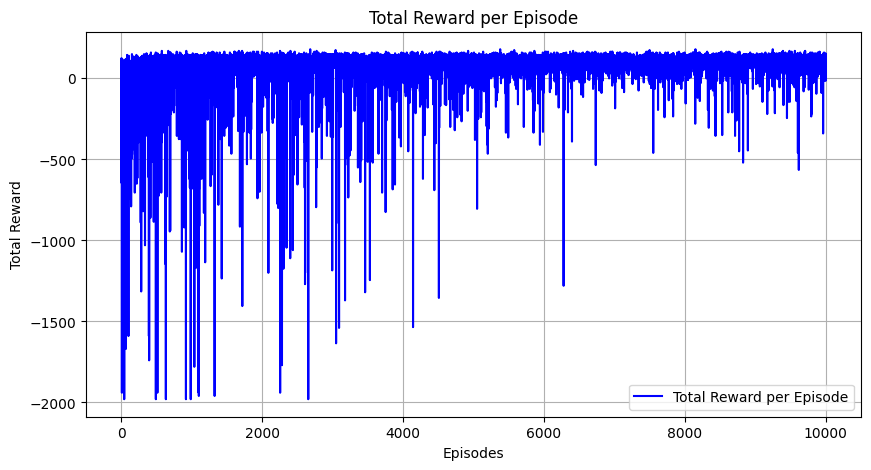

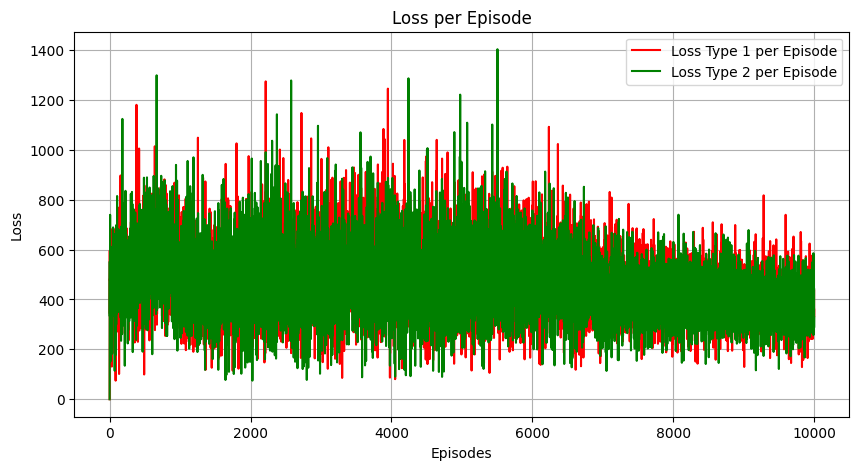

In [ ]:
visualizer = Visualization(training_initialise.score, training_initialise.losses_type_1, training_initialise.losses_type_2)
visualizer.plot_all()

In [ ]:
import numpy as np  # Ensure that numpy is imported
import random
import torch
import copy

class TestRun:
    def __init__(self, agent, env, episodes=100):
        """
        Initializes the TestRun class.

        :param agent: The trained Deep Q-learning agent.
        :param env: The environment in which the agent is tested.
        :param episodes: The number of test episodes (default is 100).
        """
        self.agent = agent  # Use the agent instance
        self.env = env
        self.episodes = episodes
        self.rewards = []  # Store the total reward for each episode
        self.steps_taken = []  # Store the number of steps per episode
        self.success_count = 0  # Store the count of successful episodes
        self.paths = []  # Store the paths taken by the agents in each episode
        self.optimal_path_diff = []  # Store the difference between actual and optimal steps
        self.episodes_within_15_steps = 0  # Store the count of episodes finished within 15 steps

    def position_flatten(self, coordinate, grid_row=5, grid_column=5):
        flatten_result = np.zeros(grid_row * grid_column)
        index = coordinate[0] * 4 + coordinate[1]
        flatten_result[index] = 1
        return flatten_result

    @staticmethod
    def manhattan_distance(coord1, coord2):
        """
        Calculate the Manhattan distance between two points in the grid.

        :param coord1: First coordinate (x, y).
        :param coord2: Second coordinate (x, y).
        :return: Manhattan distance between coord1 and coord2.
        """
        return abs(coord1[0] - coord2[0]) + abs(coord1[1] - coord2[1])

    def flatten_state(self, state, agent_idx):
        '''
        Converts the entire state (agent, B location, closest agent, and secret flag) into a flattened representation.
        '''
        agent_pos_flatten = self.position_flatten(state[0][agent_idx], grid_row=5, grid_column=5)
        B_pos_flatten = self.position_flatten(state[1], grid_row=5, grid_column=5)
        other_agent_pos = self.get_closest_agent(state[0], agent_idx)
        other_agent_pos_flatten = self.position_flatten(other_agent_pos, grid_row=5, grid_column=5)
        get_secret_flatten = np.array([1 if state[2][agent_idx] else 0])
        return np.concatenate((agent_pos_flatten, B_pos_flatten, other_agent_pos_flatten, get_secret_flatten))

    def get_closest_agent(self, agent_locations, agent_idx):
        agent_type = 0 if agent_idx < 2 else 1
        other_type_agents = agent_locations[2:] if agent_type == 0 else agent_locations[:2]
        min_dist = float('inf')
        closest_agent = other_type_agents[0]
        for loc in other_type_agents:
            dist = abs(loc[0] - agent_locations[agent_idx][0]) + abs(loc[1] - agent_locations[agent_idx][1])  # Manhattan distance
            if dist < min_dist:
                min_dist = dist
                closest_agent = loc
        return closest_agent



    def calculate_optimal_path(self, state):
        """
        Calculate the optimal path based on Manhattan distance between agents and target B.
        """
        agent_pairs = [(0, 2), (0, 3), (1, 2), (1, 3)]
        min_distance = float('inf')
        optimal_path_length = 0

        for pair in agent_pairs:
            dist_agent_0_to_b = self.manhattan_distance(state[0][pair[0]], state[1])
            dist_agent_1_to_b = self.manhattan_distance(state[0][pair[1]], state[1])
            shortest_to_b = min(dist_agent_0_to_b, dist_agent_1_to_b)
            pair_distance = self.manhattan_distance(state[0][pair[0]], state[0][pair[1]])
            total_distance = shortest_to_b + pair_distance

            if total_distance < min_distance:
                min_distance = total_distance
                optimal_path_length = total_distance

        return optimal_path_length

    def run(self):
        """
        Run the test episodes using the trained agents.
        """
        max_episode_limit = self.episodes
        max_step_limit = 100

        for episode in range(max_episode_limit):

            initial_state = self.env.reset_state()
            episode_reward = 0


            current_states = [self.flatten_state(initial_state, i) for i in range(4)]

            for step in range(max_step_limit):

                agent_indices = [0, 1, 2, 3]
                random.shuffle(agent_indices)  # Shuffle the order of agents to update randomly
                for agent_idx in agent_indices:
                    model_type = 1 if agent_idx < 2 else 2

                    next_action = np.argmax(self.agent.get_qvals(current_states[agent_idx], model_type))

                    next_state, reward, done = self.env.step(agent_idx, next_action)
                    next_state_flatten = self.flatten_state(next_state, agent_idx)

                    episode_reward += reward

                    # Update the state
                    current_states[agent_idx] = next_state_flatten

                    if done:

                        self.success_count += 1
                        break

                if done:
                    break

            # Calculate optimal path length for the current episode
            optimal_path_length = self.calculate_optimal_path(initial_state)
            excess_steps = step + 1 - optimal_path_length
            self.optimal_path_diff.append(excess_steps)

            # Count episodes finished within 15 steps
            if step + 1 <= 15:
                self.episodes_within_15_steps += 1

            # Store the results for this episode
            self.rewards.append(episode_reward)
            self.steps_taken.append(step + 1)

            print(f"Test Episode {episode + 1}: Steps Taken = {step + 1}, Total Reward = {episode_reward}")

    def evaluate_results(self):
        """
        Evaluate and print the results of the test run.
        Calculate the average reward, steps, and success rate.
        """
        avg_reward = np.mean(self.rewards)
        avg_steps = np.mean(self.steps_taken)
        success_rate = (self.success_count / self.episodes) * 100
        avg_excess_steps = np.mean(self.optimal_path_diff)
        percentage_within_15_steps = (self.episodes_within_15_steps / self.episodes) * 100

        print("\nEvaluation Results:")
        print(f"Average Reward: {avg_reward}")
        print(f"Average Steps: {avg_steps}")
        print(f"Success Rate: {success_rate}%")
        print(f"Average Excess Optimal Steps: {avg_excess_steps}")
        print(f"Percentage of Episodes Finished Within 15 Steps: {percentage_within_15_steps}%")

In [ ]:
test_run = TestRun(deep_q_agents, env_initialise, episodes=100)  # Test the trained agents
test_run.run()                                                   # Run the test episodes using the trained models
test_run.evaluate_results()                                      # Evaluate the results

Test Episode 1: Steps Taken = 4, Total Reward = 105
Test Episode 2: Steps Taken = 3, Total Reward = 145
Test Episode 3: Steps Taken = 100, Total Reward = -1940
Test Episode 4: Steps Taken = 3, Total Reward = 120
Test Episode 5: Steps Taken = 3, Total Reward = 125
Test Episode 6: Steps Taken = 4, Total Reward = 110
Test Episode 7: Steps Taken = 3, Total Reward = 115
Test Episode 8: Steps Taken = 3, Total Reward = 125
Test Episode 9: Steps Taken = 7, Total Reward = 80
Test Episode 10: Steps Taken = 2, Total Reward = 140
Test Episode 11: Steps Taken = 4, Total Reward = 105
Test Episode 12: Steps Taken = 4, Total Reward = 120
Test Episode 13: Steps Taken = 3, Total Reward = 130
Test Episode 14: Steps Taken = 3, Total Reward = 115
Test Episode 15: Steps Taken = 10, Total Reward = 5
Test Episode 16: Steps Taken = 7, Total Reward = 50
Test Episode 17: Steps Taken = 5, Total Reward = 115
Test Episode 18: Steps Taken = 3, Total Reward = 145
Test Episode 19: Steps Taken = 4, Total Reward = 105
T

In [ ]:
import numpy as np  # Ensure that numpy is imported
import random
import torch
import copy

class TestRun:
    def __init__(self, agent, env, episodes=100):
        """
        Initializes the TestRun class.

        :param agent: The trained Deep Q-learning agent.
        :param env: The environment in which the agent is tested.
        :param episodes: The number of test episodes (default is 100).
        """
        self.agent = agent  # Use the agent instance
        self.env = env
        self.episodes = episodes
        self.rewards = []  # Store the total reward for each episode
        self.steps_taken = []  # Store the number of steps per episode
        self.success_count = 0  # Store the count of successful episodes
        self.paths = []  # Store the paths taken by the agents in each episode
        self.optimal_path_diff = []  # Store the difference between actual and optimal steps
        self.episodes_within_15_steps = 0  # Store the count of episodes finished within 15 steps

    def position_flatten(self, coordinate, grid_row=5, grid_column=5):
        '''
        Converts a 2D grid coordinate to a 1D flattened state representation.
        '''


        flatten_result = np.zeros(grid_row * grid_column)
        index = coordinate[0] * 4 + coordinate[1]
        flatten_result[index] = 1
        return flatten_result

    @staticmethod
    def manhattan_distance(coord1, coord2):
        """
        Calculate the Manhattan distance between two points in the grid.

        :param coord1: First coordinate (x, y).
        :param coord2: Second coordinate (x, y).
        :return: Manhattan distance between coord1 and coord2.
        """
        return abs(coord1[0] - coord2[0]) + abs(coord1[1] - coord2[1])

    def flatten_state(self, state, agent_idx):
        '''
        Converts the entire state (agent, B location, closest agent, and secret flag) into a flattened representation.
        '''
        agent_pos_flatten = self.position_flatten(state[0][agent_idx], grid_row=5, grid_column=5)
        B_pos_flatten = self.position_flatten(state[1], grid_row=5, grid_column=5)
        other_agent_pos = self.get_closest_agent(state[0], agent_idx)
        other_agent_pos_flatten = self.position_flatten(other_agent_pos, grid_row=5, grid_column=5)
        get_secret_flatten = np.array([1 if state[2][agent_idx] else 0])
        return np.concatenate((agent_pos_flatten, B_pos_flatten, other_agent_pos_flatten, get_secret_flatten))

    def get_closest_agent(self, agent_locations, agent_idx):
        agent_type = 0 if agent_idx < 2 else 1
        other_type_agents = agent_locations[2:] if agent_type == 0 else agent_locations[:2]
        min_dist = float('inf')
        closest_agent = other_type_agents[0]
        for loc in other_type_agents:
            dist = abs(loc[0] - agent_locations[agent_idx][0]) + abs(loc[1] - agent_locations[agent_idx][1])  # Manhattan distance
            if dist < min_dist:
                min_dist = dist
                closest_agent = loc
        return closest_agent



    def calculate_optimal_path(self, state):
        """
        Calculate the optimal path based on Manhattan distance between agents and target B.
        """
        agent_pairs = [(0, 2), (0, 3), (1, 2), (1, 3)]
        min_distance = float('inf')
        optimal_path_length = 0

        for pair in agent_pairs:
            dist_agent_0_to_b = self.manhattan_distance(state[0][pair[0]], state[1])
            dist_agent_1_to_b = self.manhattan_distance(state[0][pair[1]], state[1])
            shortest_to_b = min(dist_agent_0_to_b, dist_agent_1_to_b)
            pair_distance = self.manhattan_distance(state[0][pair[0]], state[0][pair[1]])
            total_distance = shortest_to_b + pair_distance

            if total_distance < min_distance:
                min_distance = total_distance
                optimal_path_length = total_distance

        return optimal_path_length

    def run(self):
        """
        Run the test episodes using the trained agents.
        """
        max_episode_limit = self.episodes
        max_step_limit = 100

        for episode in range(max_episode_limit):

            initial_state = self.env.reset_state()
            episode_reward = 0




            for step in range(max_step_limit):

                agent_indices = [0, 1, 2, 3]
                random.shuffle(agent_indices)  # Shuffle the order of agents to update randomly
                for agent_idx in agent_indices:
                    model_type = 1 if agent_idx < 2 else 2

                    next_action = np.argmax(self.agent.get_qvals(self.flatten_state(initial_state, agent_idx), model_type))

                    next_state, reward, done = self.env.step(agent_idx, next_action)


                    episode_reward += reward

                    # Update the state
                    initial_state = next_state

                    if done:

                        self.success_count += 1
                        break

                if done:
                    break

            # Calculate optimal path length for the current episode
            optimal_path_length = self.calculate_optimal_path(initial_state)
            excess_steps = step + 1 - optimal_path_length
            self.optimal_path_diff.append(excess_steps)

            # Count episodes finished within 15 steps
            if step + 1 <= 15:
                self.episodes_within_15_steps += 1

            # Store the results for this episode
            self.rewards.append(episode_reward)
            self.steps_taken.append(step + 1)

            print(f"Test Episode {episode + 1}: Steps Taken = {step + 1}, Total Reward = {episode_reward}")

    def evaluate_results(self):
        """
        Evaluate and print the results of the test run.
        Calculate the average reward, steps, and success rate.
        """
        avg_reward = np.mean(self.rewards)
        avg_steps = np.mean(self.steps_taken)
        success_rate = (self.success_count / self.episodes) * 100
        avg_excess_steps = np.mean(self.optimal_path_diff)
        percentage_within_15_steps = (self.episodes_within_15_steps / self.episodes) * 100

        print("\nEvaluation Results:")
        print(f"Average Reward: {avg_reward}")
        print(f"Average Steps: {avg_steps}")
        print(f"Success Rate: {success_rate}%")
        print(f"Average Excess Optimal Steps: {avg_excess_steps}")
        print(f"Percentage of Episodes Finished Within 15 Steps: {percentage_within_15_steps}%")

In [ ]:
test_run = TestRun(deep_q_agents, env_initialise, episodes=100)  # Test the trained agents
test_run.run()                                                   # Run the test episodes using the trained models
test_run.evaluate_results()                                      # Evaluate the results

Test Episode 1: Steps Taken = 3, Total Reward = 135
Test Episode 2: Steps Taken = 4, Total Reward = 100
Test Episode 3: Steps Taken = 3, Total Reward = 145
Test Episode 4: Steps Taken = 100, Total Reward = -1940
Test Episode 5: Steps Taken = 2, Total Reward = 150
Test Episode 6: Steps Taken = 3, Total Reward = 115
Test Episode 7: Steps Taken = 4, Total Reward = 110
Test Episode 8: Steps Taken = 3, Total Reward = 120
Test Episode 9: Steps Taken = 2, Total Reward = 130
Test Episode 10: Steps Taken = 3, Total Reward = 140
Test Episode 11: Steps Taken = 8, Total Reward = 65
Test Episode 12: Steps Taken = 4, Total Reward = 95
Test Episode 13: Steps Taken = 3, Total Reward = 145
Test Episode 14: Steps Taken = 3, Total Reward = 125
Test Episode 15: Steps Taken = 6, Total Reward = 50
Test Episode 16: Steps Taken = 3, Total Reward = 140
Test Episode 17: Steps Taken = 4, Total Reward = 125
Test Episode 18: Steps Taken = 3, Total Reward = 145
Test Episode 19: Steps Taken = 3, Total Reward = 145
T

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
import copy

class TestRun:
    def __init__(self, agent, env, episodes=100):
        """
        Initializes the TestRun class.

        :param agent: The trained Deep Q-learning agent.
        :param env: The environment in which the agent is tested.
        :param episodes: The number of test episodes (default is 100).
        """
        self.agent = agent  # Use the agent instance
        self.env = env
        self.episodes = episodes
        self.rewards = []  # Store the total reward for each episode
        self.steps_taken = []  # Store the number of steps per episode
        self.success_count = 0  # Store the count of successful episodes
        self.paths = []  # Store the paths taken by the agents in each episode
        self.optimal_path_diff = []  # Store the difference between actual and optimal steps
        self.episodes_within_15_steps = 0  # Store the count of episodes finished within 15 steps

    def position_flatten(self, coordinate, grid_row=5, grid_column=5):
        '''
        Converts a 2D grid coordinate to a 1D flattened state representation.
        '''
        if coordinate[0] >= grid_column or coordinate[1] >= grid_row:
            return np.zeros(grid_row * grid_column)  # Return a zero vector if out of bounds
        elif coordinate[0] < 0:
            return np.zeros(grid_row * grid_column)  # Handle invalid positions

        flatten_result = np.zeros(grid_row * grid_column)
        index = coordinate[0] * 4 + coordinate[1]
        flatten_result[index] = 1
        return flatten_result

    @staticmethod
    def manhattan_distance(coord1, coord2):
        """
        Calculate the Manhattan distance between two points in the grid.

        :param coord1: First coordinate (x, y).
        :param coord2: Second coordinate (x, y).
        :return: Manhattan distance between coord1 and coord2.
        """
        return abs(coord1[0] - coord2[0]) + abs(coord1[1] - coord2[1])

    def flatten_state(self, state, agent_idx):
        '''
        Converts the entire state (agent, B location, closest agent, and secret flag) into a flattened representation.
        '''
        agent_pos_flatten = self.position_flatten(state[0][agent_idx], grid_row=5, grid_column=5)
        B_pos_flatten = self.position_flatten(state[1], grid_row=5, grid_column=5)
        other_agent_pos = self.get_closest_agent(state[0], agent_idx)
        other_agent_pos_flatten = self.position_flatten(other_agent_pos, grid_row=5, grid_column=5)
        get_secret_flatten = np.array([1 if state[2][agent_idx] else 0])
        return np.concatenate((agent_pos_flatten, B_pos_flatten, other_agent_pos_flatten, get_secret_flatten))

    def get_closest_agent(self, agent_locations, agent_idx):
        agent_type = 0 if agent_idx < 2 else 1
        other_type_agents = agent_locations[2:] if agent_type == 0 else agent_locations[:2]
        min_dist = float('inf')
        closest_agent = other_type_agents[0]
        for loc in other_type_agents:
            dist = abs(loc[0] - agent_locations[agent_idx][0]) + abs(loc[1] - agent_locations[agent_idx][1])  # Manhattan distance
            if dist < min_dist:
                min_dist = dist
                closest_agent = loc
        return closest_agent

    def plot_grid(self, state, episode, step):
        """
        Plot the current grid state showing the positions of agents and target B.
        """
        plt.figure(figsize=(6, 6))
        grid = np.zeros((self.env.length, self.env.width))

        # Plot agents
        for idx, agent_pos in enumerate(state[0]):
            grid[agent_pos[0], agent_pos[1]] = idx + 1

        # Plot target B
        grid[state[1][0], state[1][1]] = 5

        plt.imshow(grid, cmap='viridis', origin='upper')
        plt.title(f'Episode {episode + 1}, Step {step + 1}')
        plt.colorbar(ticks=[0, 1, 2, 3, 4, 5], label='0: Empty, 1-4: Agents, 5: Target B')
        plt.grid(True)
        plt.show()



    def run(self):
        """
        Run the test episodes using the trained agents.
        """
        max_episode_limit = self.episodes
        max_step_limit = 100

        for episode in range(max_episode_limit):

            initial_state = self.env.reset_state()
            episode_reward = 0


            current_states = [self.flatten_state(initial_state, i) for i in range(4)]

            for step in range(max_step_limit):
                self.plot_grid(initial_state, episode, step)
                agent_indices = [0, 1, 2, 3]
                random.shuffle(agent_indices)  # Shuffle the order of agents to update randomly
                for agent_idx in agent_indices:
                    model_type = 1 if agent_idx < 2 else 2

                    next_action = np.argmax(self.agent.get_qvals(current_states[agent_idx], model_type))

                    next_state, reward, done = self.env.step(agent_idx, next_action)
                    next_state_flatten = self.flatten_state(next_state, agent_idx)

                    episode_reward += reward

                    # Update the state
                    current_states[agent_idx] = next_state_flatten

                    if done:
                        self.plot_grid(initial_state, episode, step)
                        self.success_count += 1
                        break

                if done:
                    break



            print(f"Test Episode {episode + 1}: Steps Taken = {step + 1}, Total Reward = {episode_reward}")



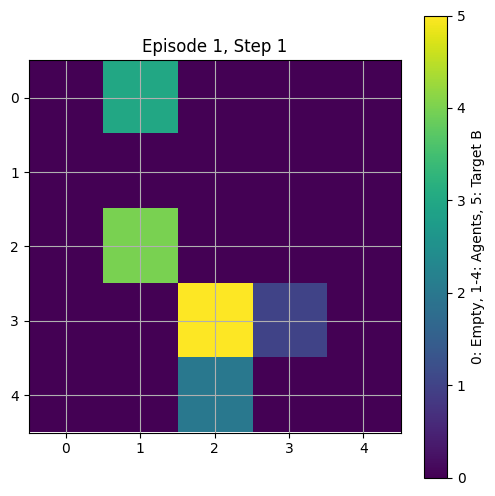

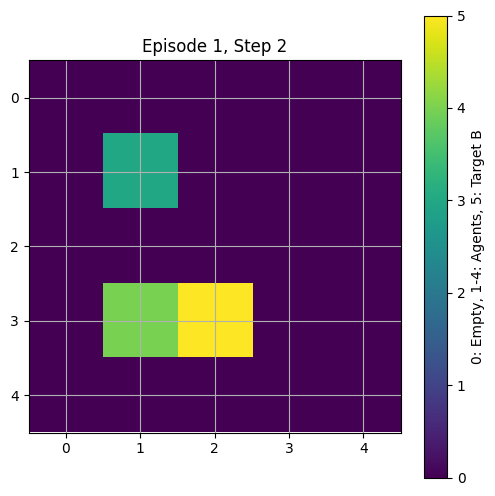

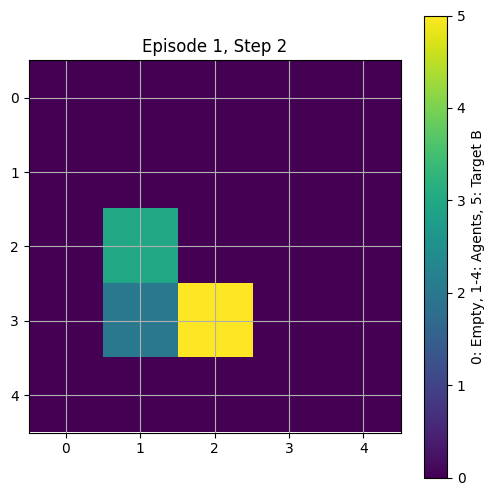

Test Episode 1: Steps Taken = 2, Total Reward = 135


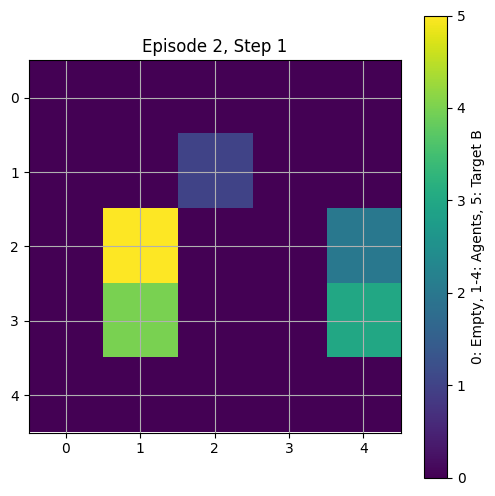

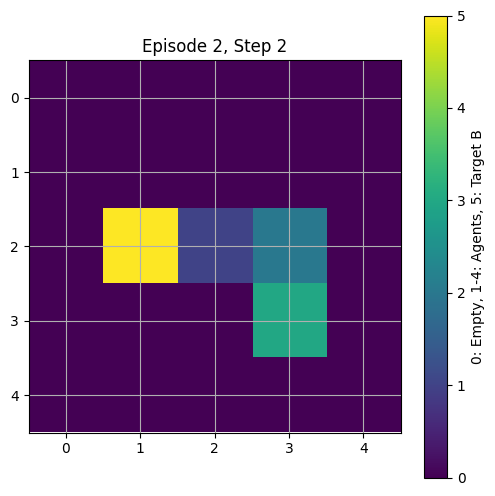

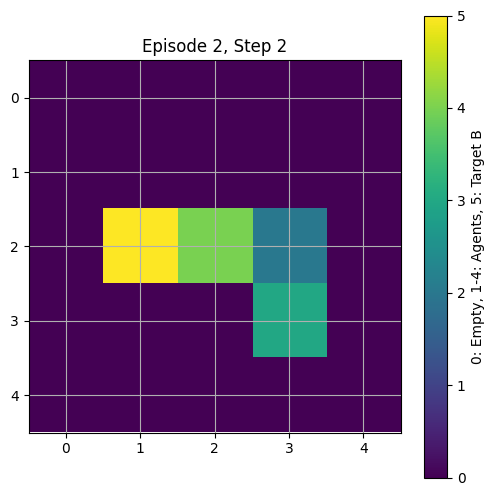

Test Episode 2: Steps Taken = 2, Total Reward = 140


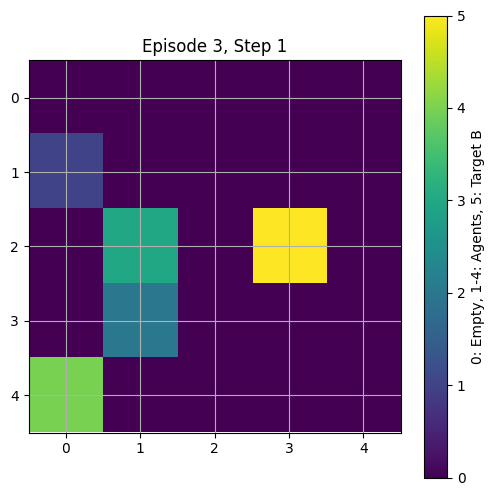

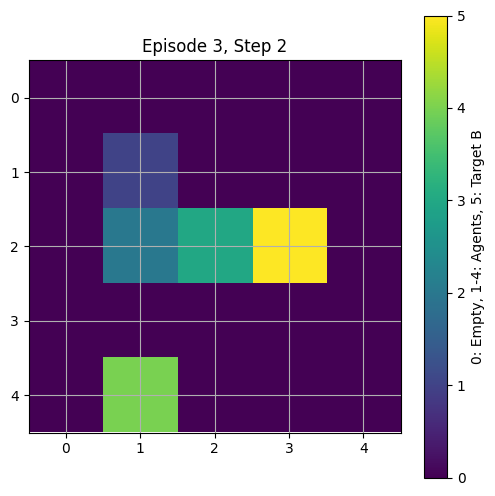

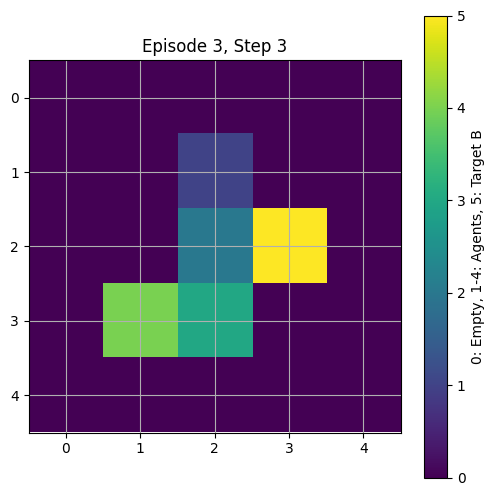

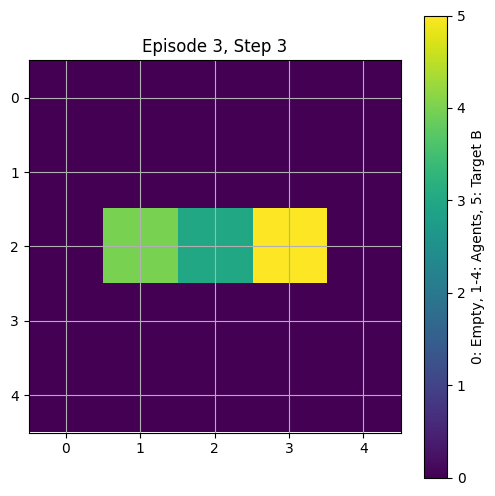

Test Episode 3: Steps Taken = 3, Total Reward = 130


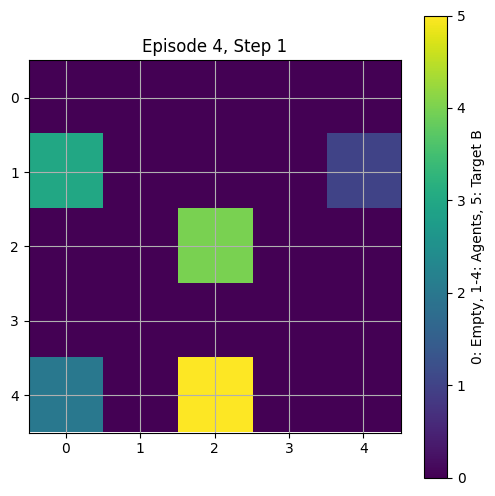

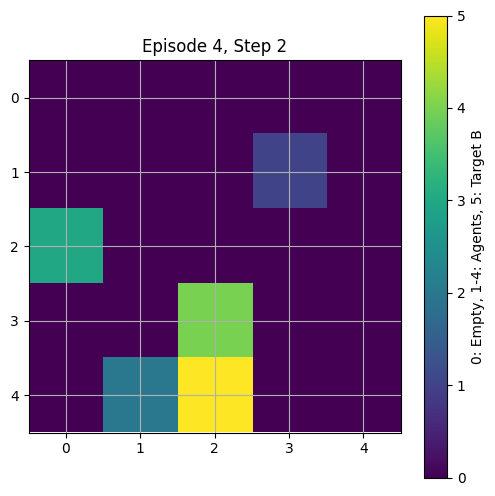

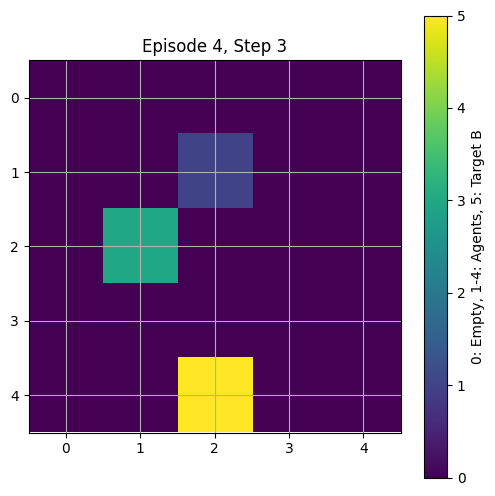

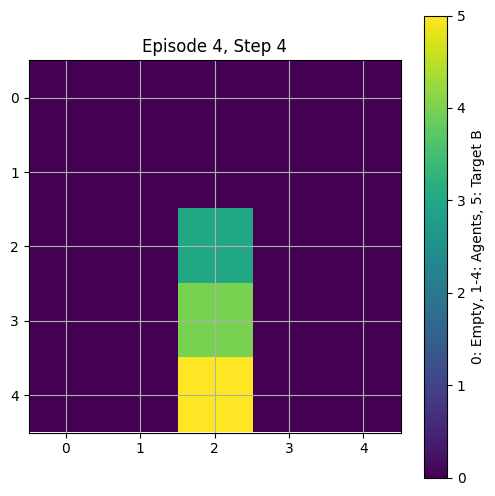

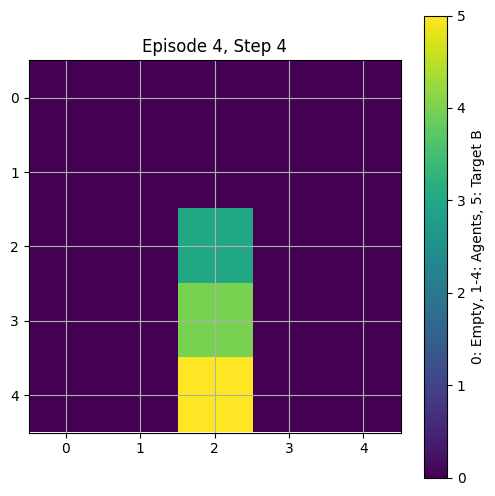

Test Episode 4: Steps Taken = 4, Total Reward = 125


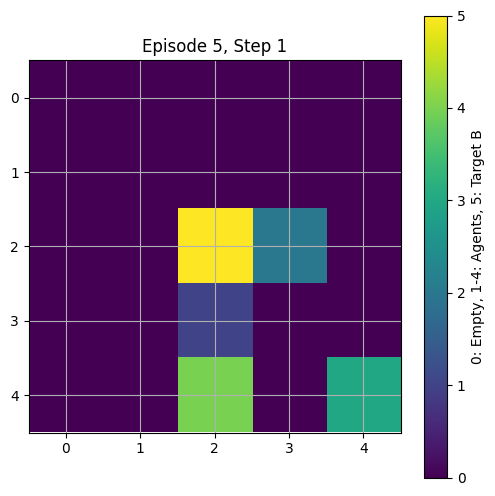

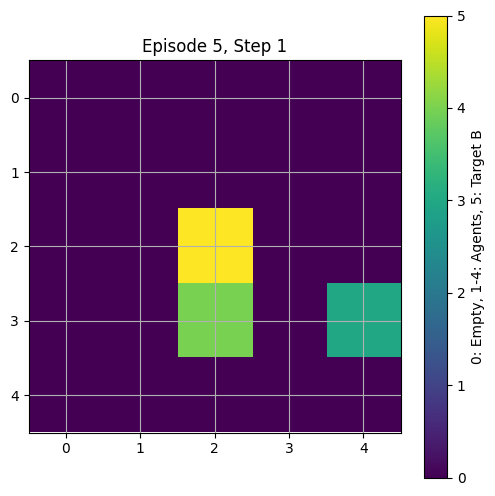

Test Episode 5: Steps Taken = 1, Total Reward = 150


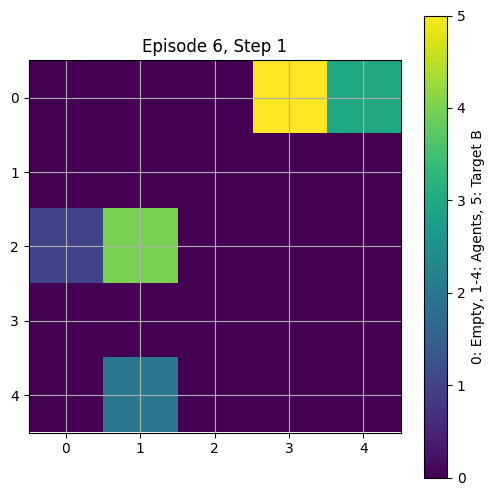

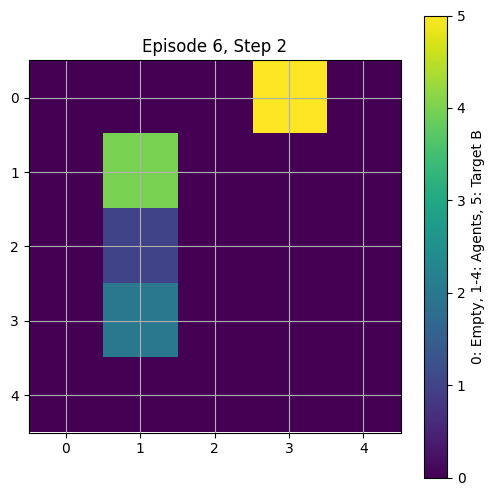

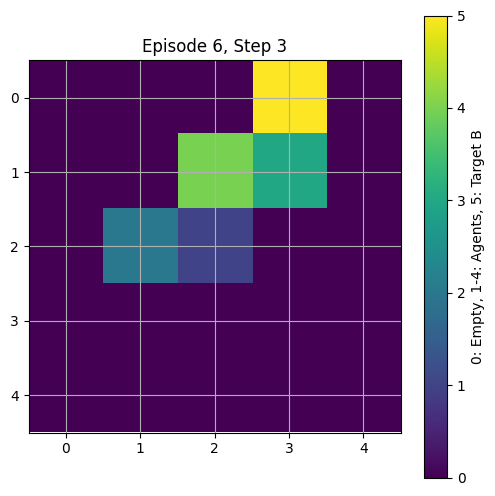

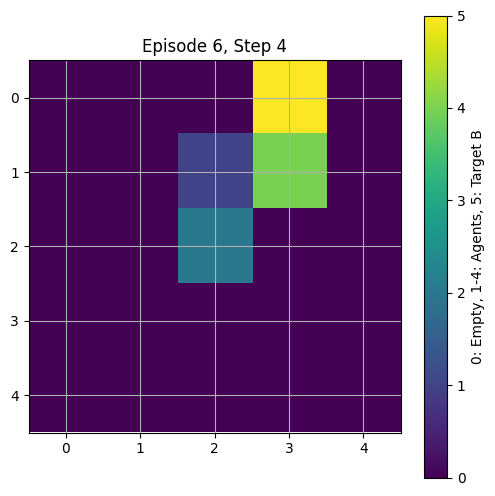

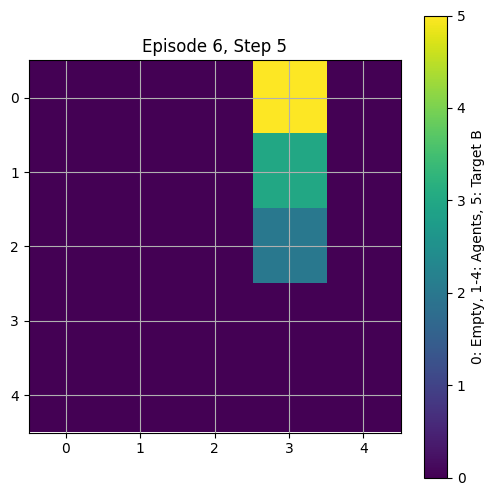

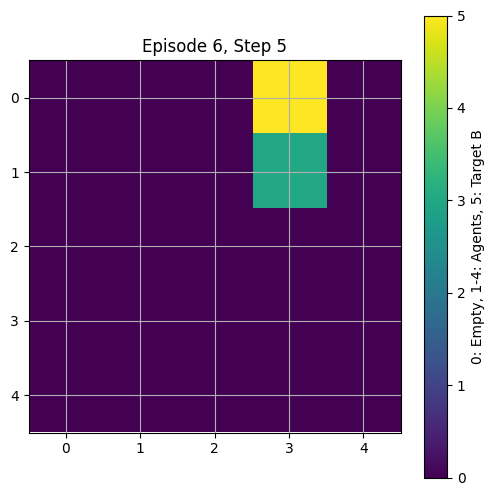

Test Episode 6: Steps Taken = 5, Total Reward = 100


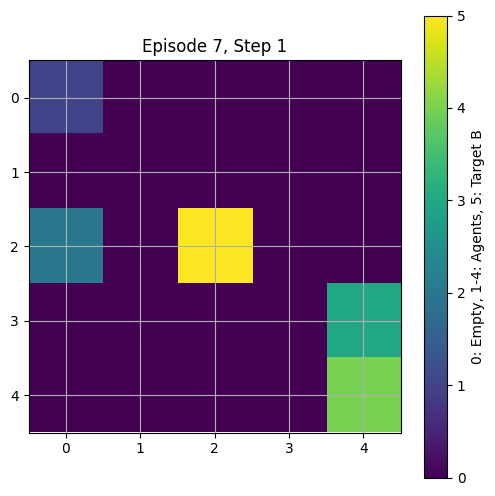

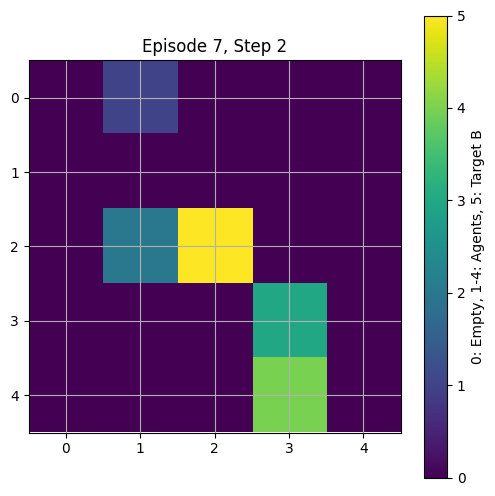

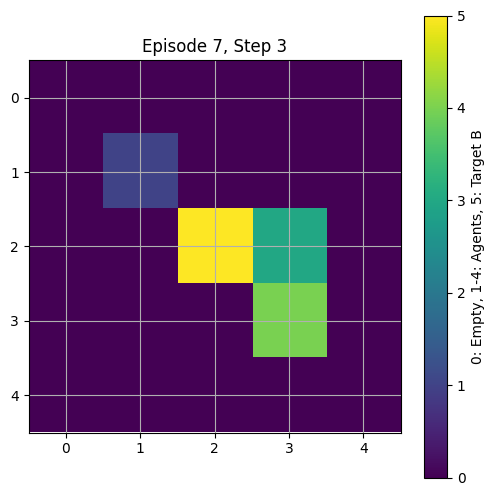

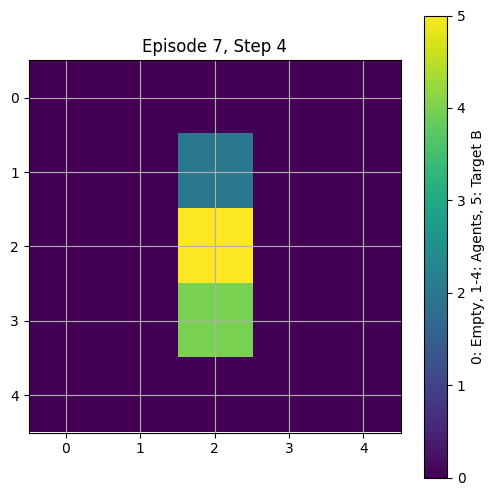

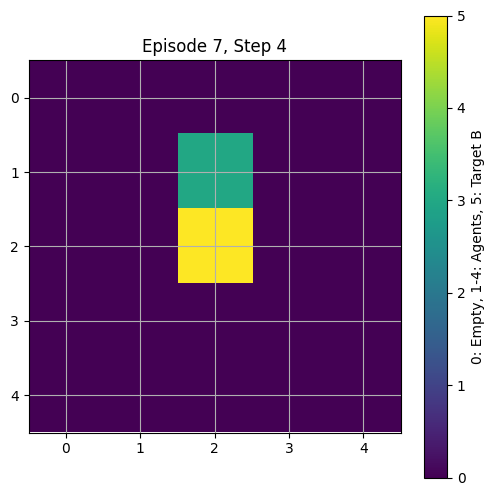

Test Episode 7: Steps Taken = 4, Total Reward = 95


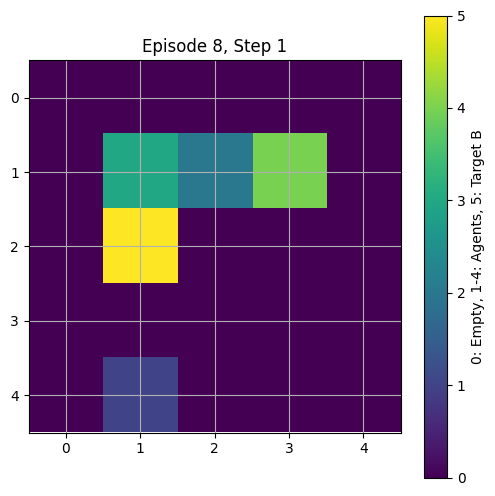

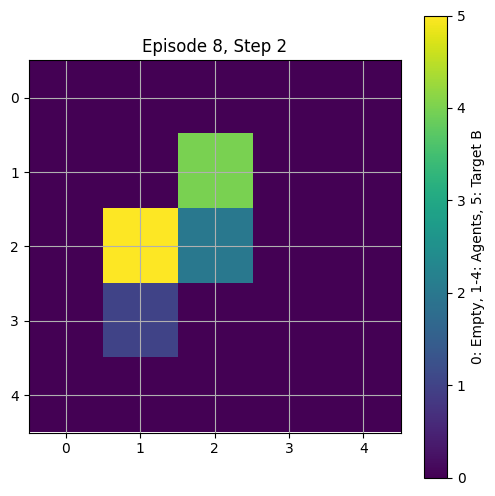

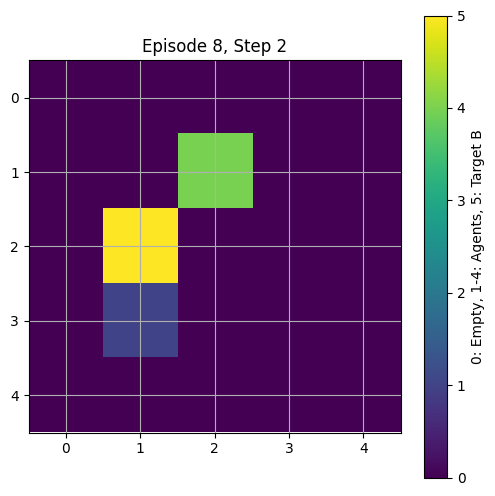

Test Episode 8: Steps Taken = 2, Total Reward = 145


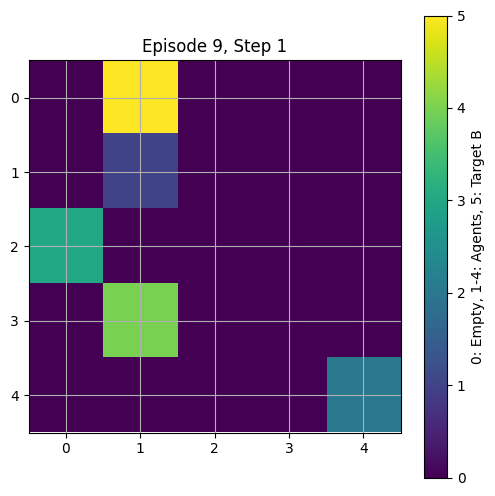

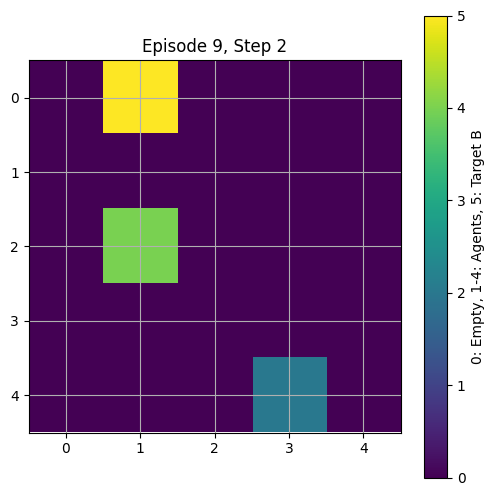

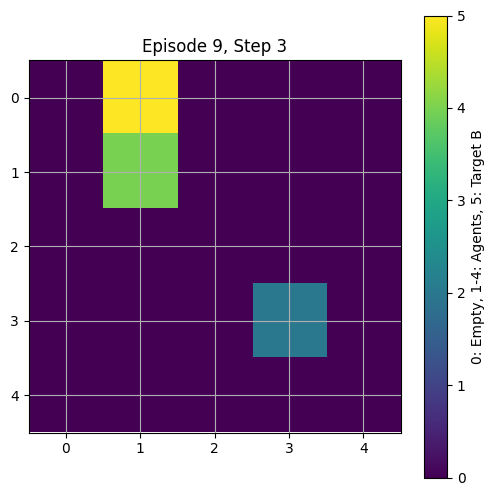

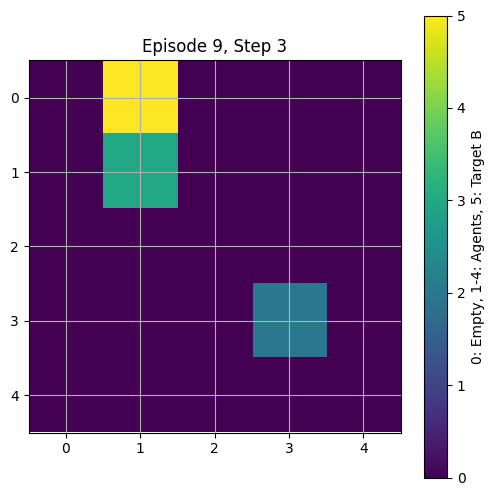

Test Episode 9: Steps Taken = 3, Total Reward = 145


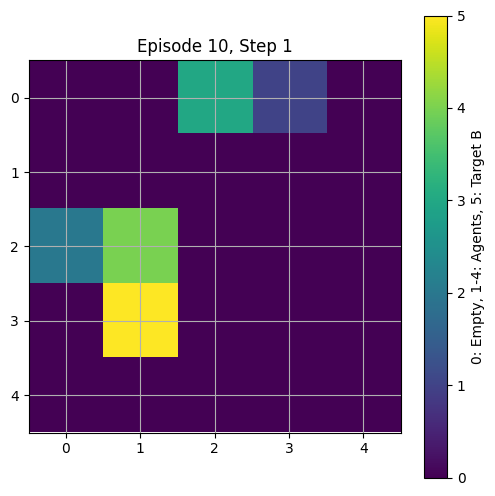

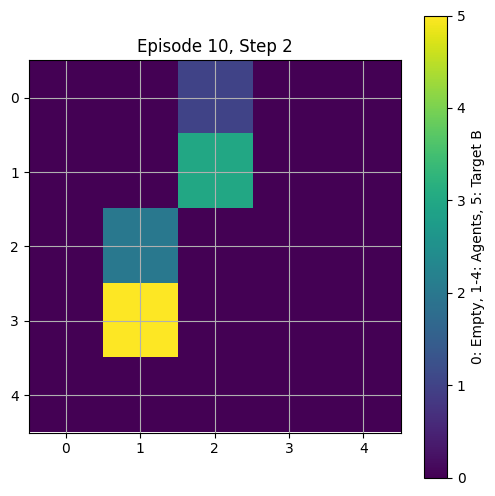

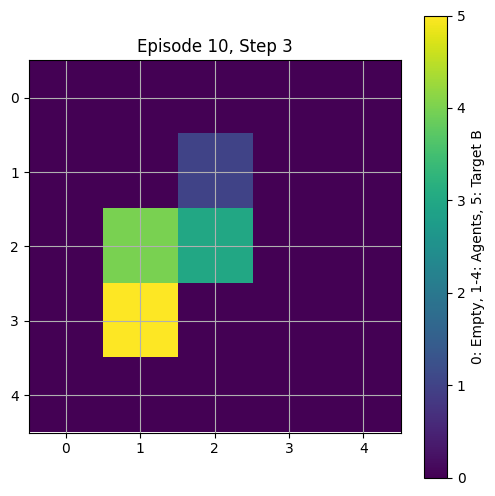

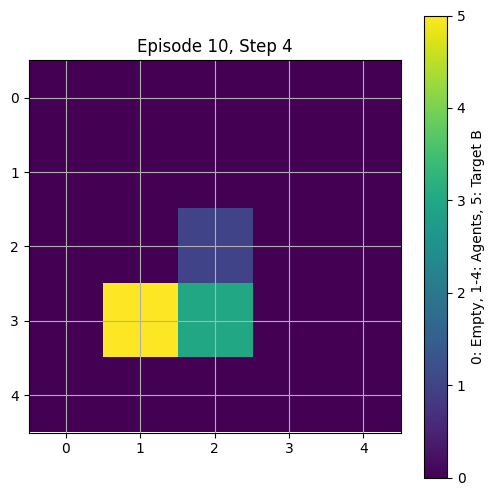

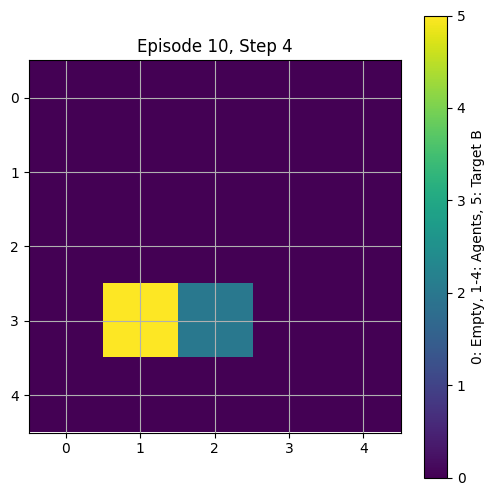

Test Episode 10: Steps Taken = 4, Total Reward = 100


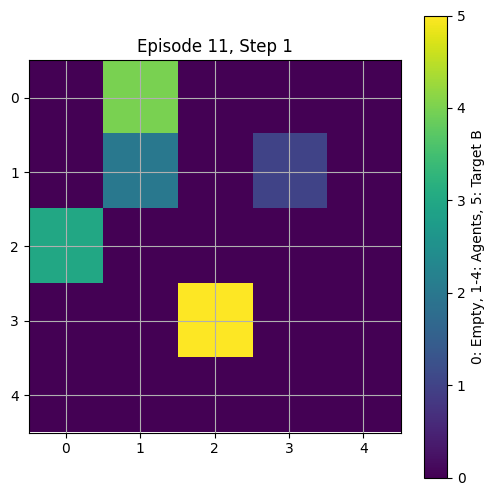

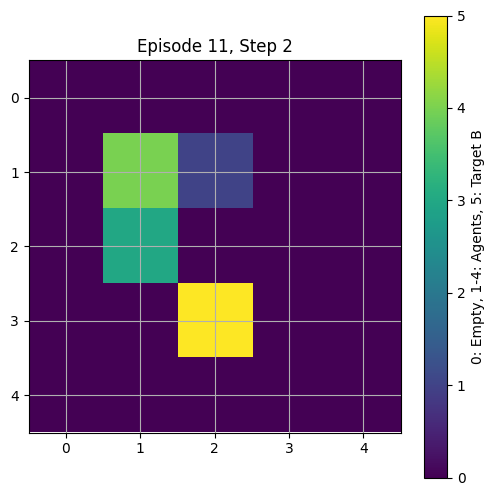

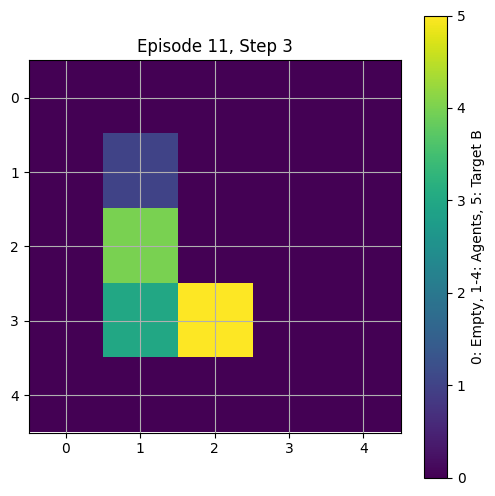

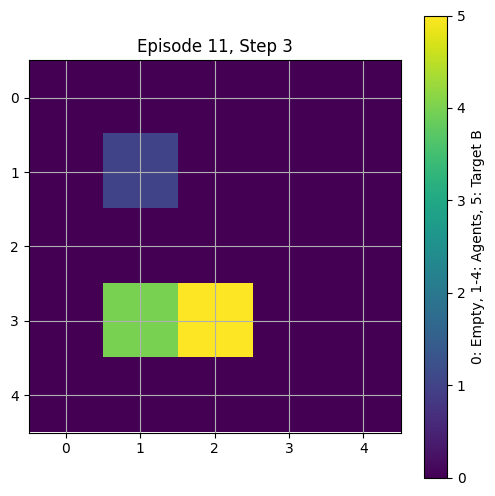

Test Episode 11: Steps Taken = 3, Total Reward = 160


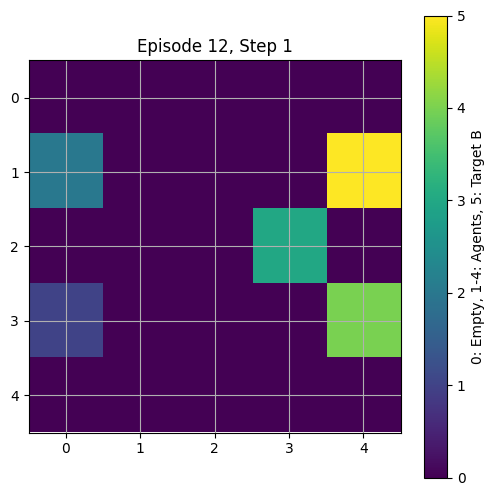

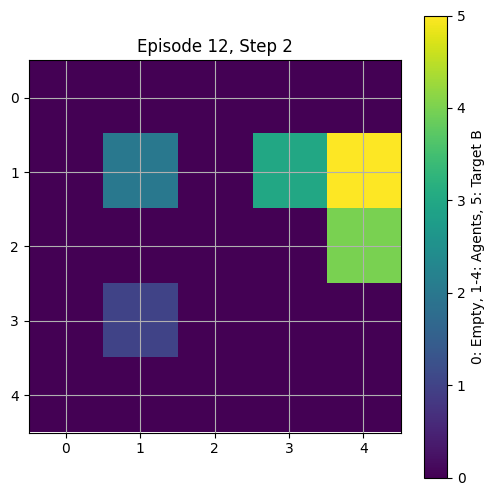

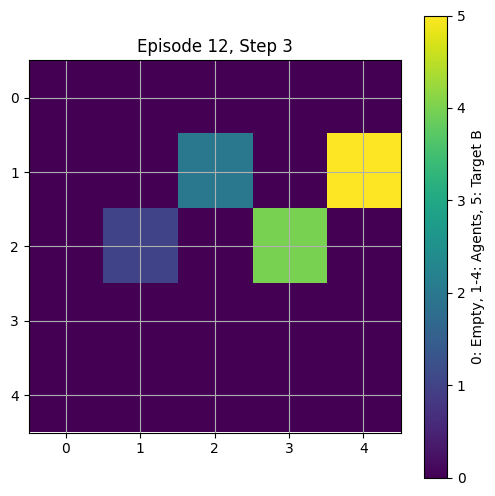

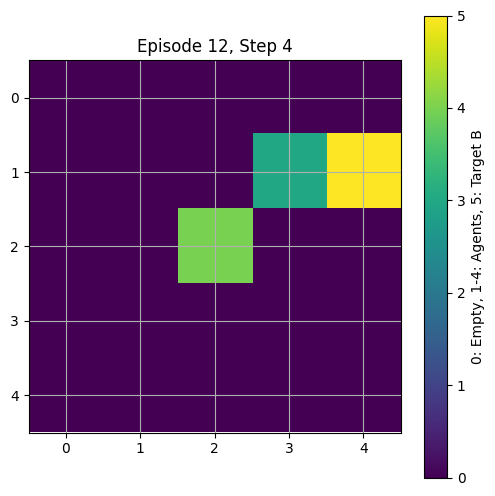

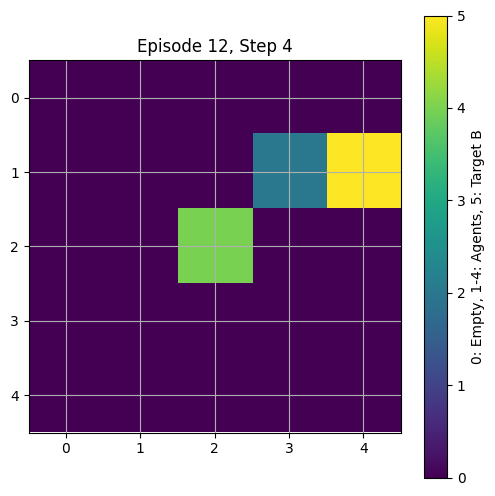

Test Episode 12: Steps Taken = 4, Total Reward = 125


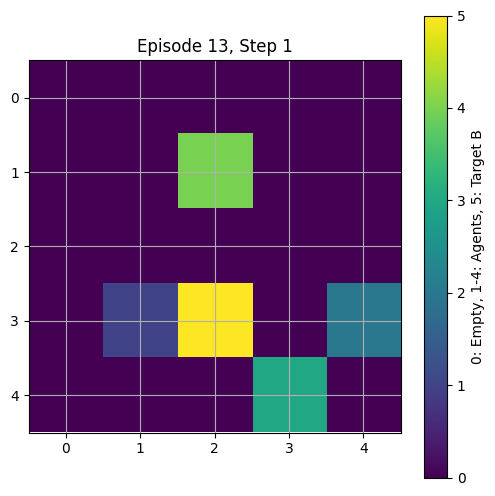

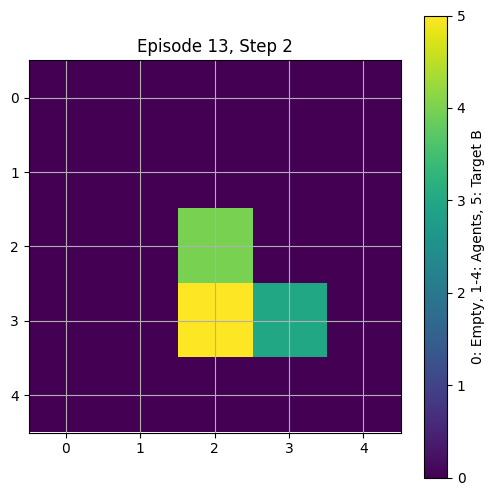

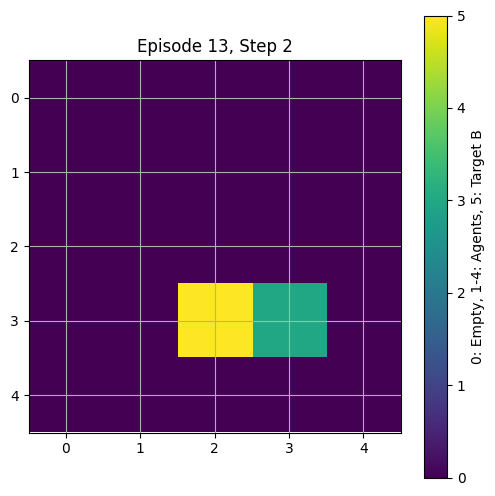

Test Episode 13: Steps Taken = 2, Total Reward = 140


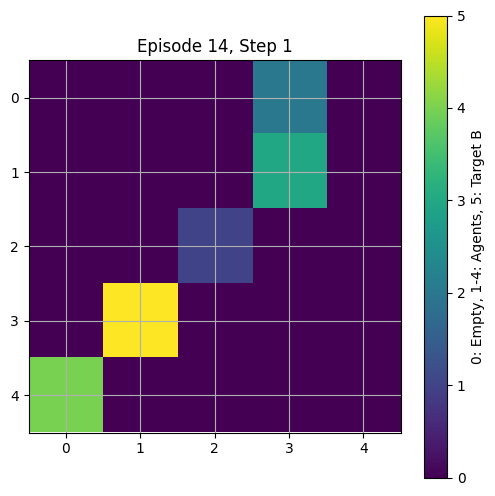

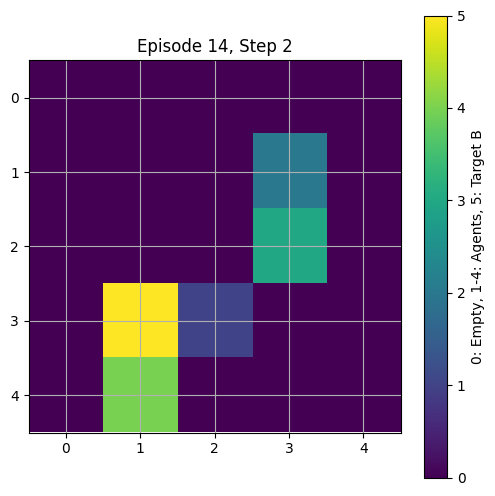

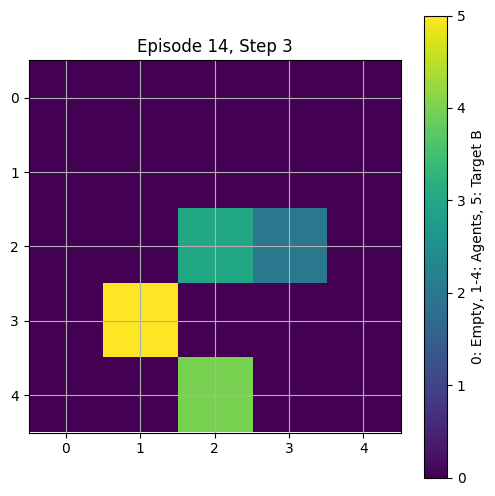

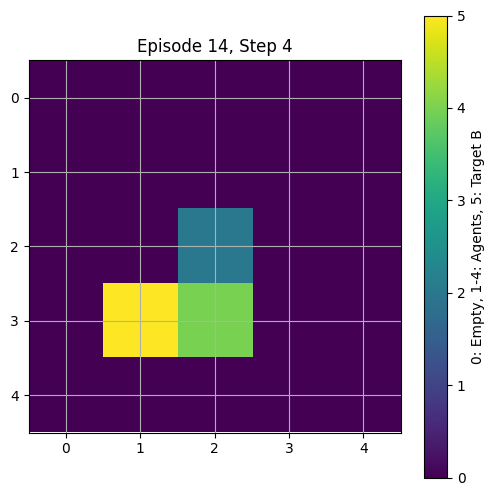

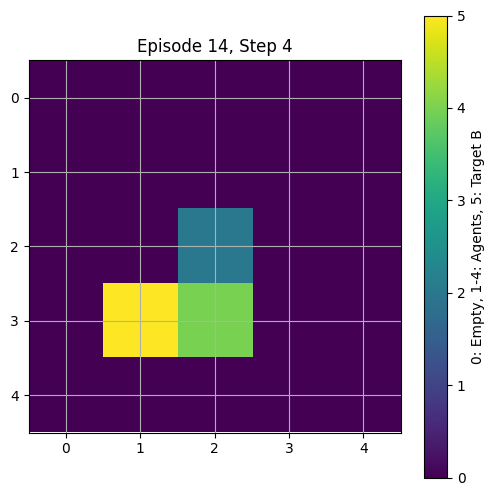

Test Episode 14: Steps Taken = 4, Total Reward = 125


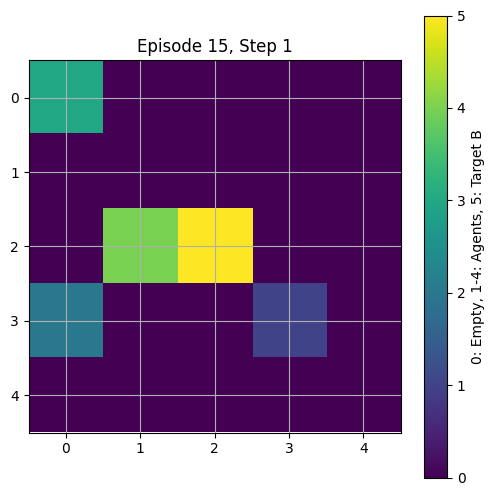

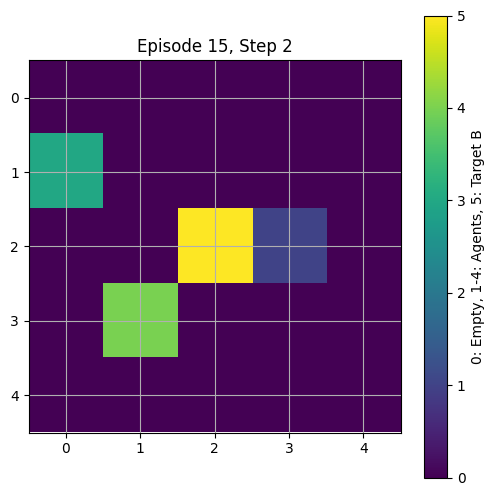

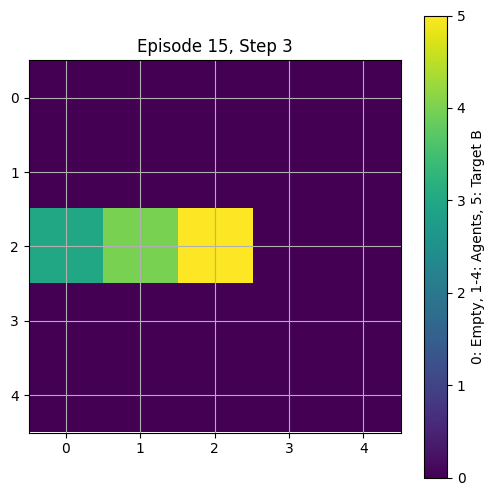

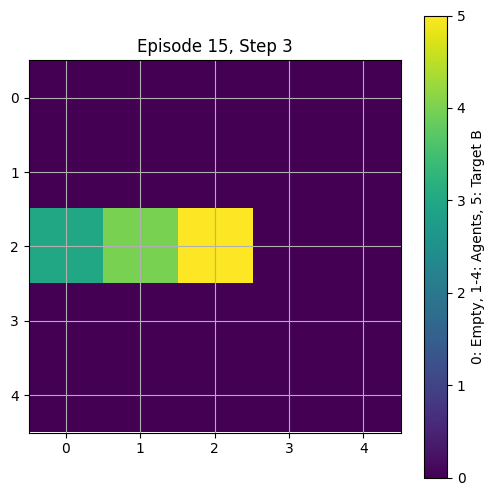

Test Episode 15: Steps Taken = 3, Total Reward = 140


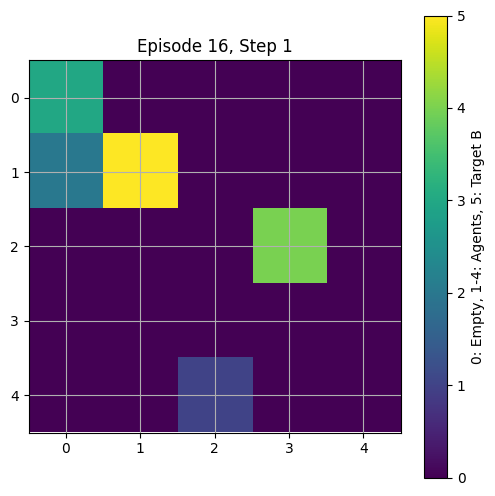

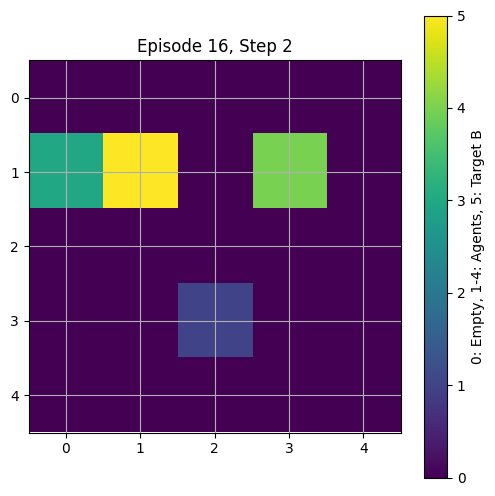

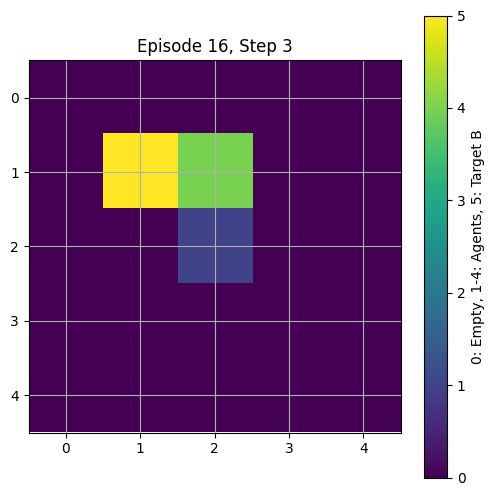

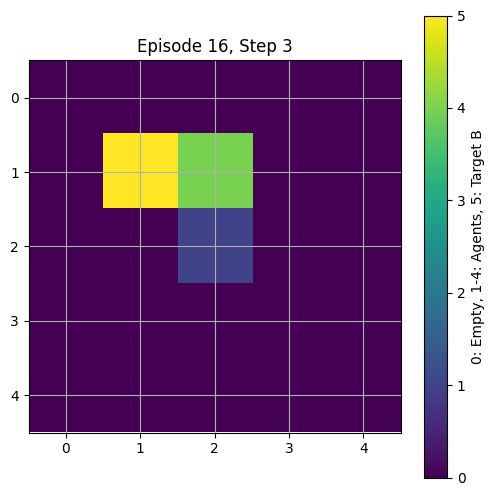

Test Episode 16: Steps Taken = 3, Total Reward = 125


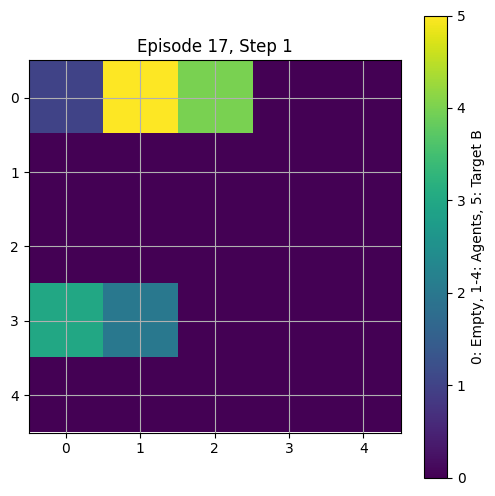

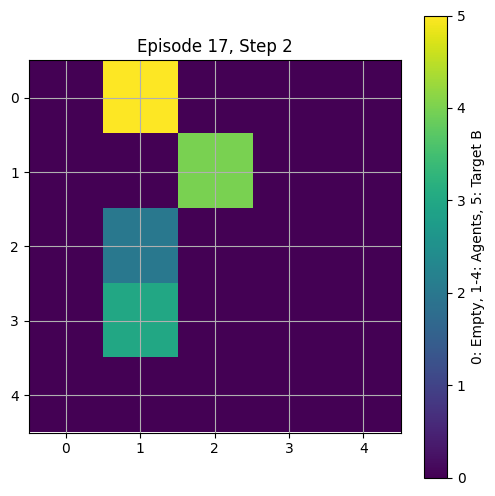

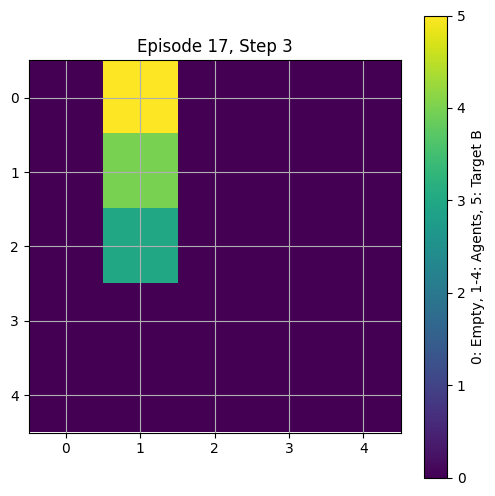

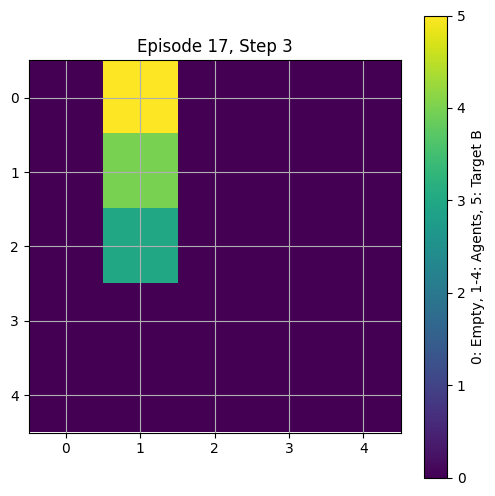

Test Episode 17: Steps Taken = 3, Total Reward = 145


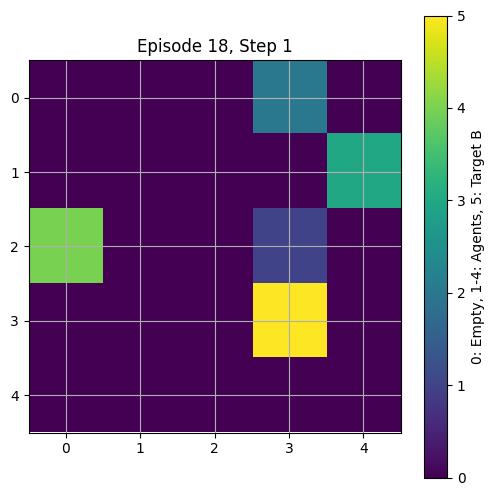

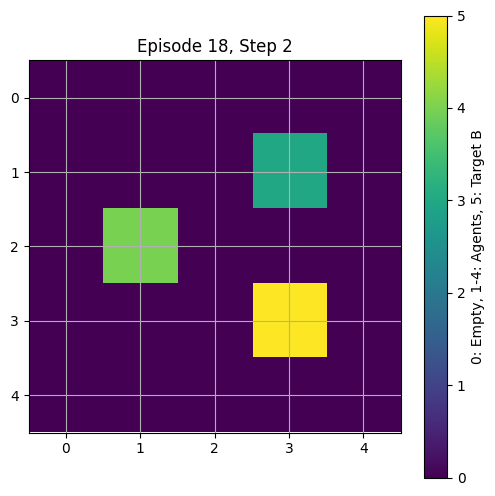

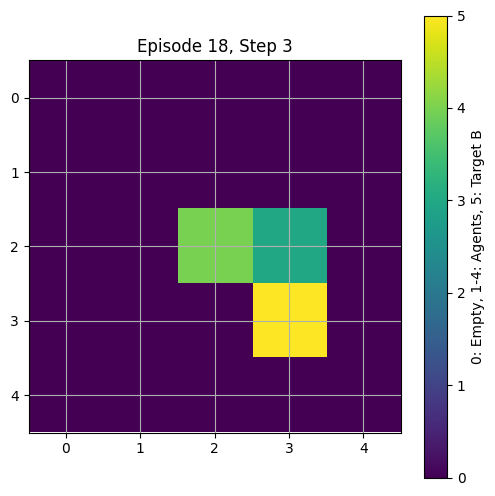

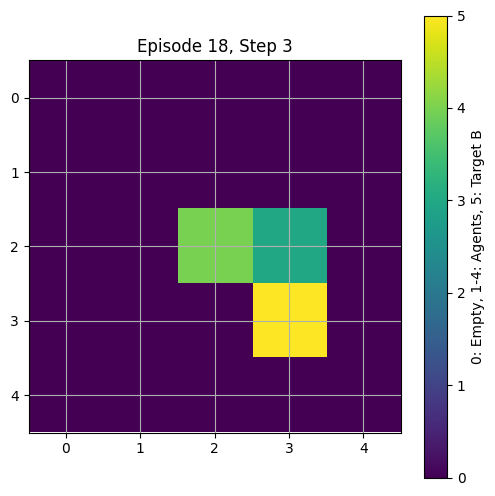

Test Episode 18: Steps Taken = 3, Total Reward = 145


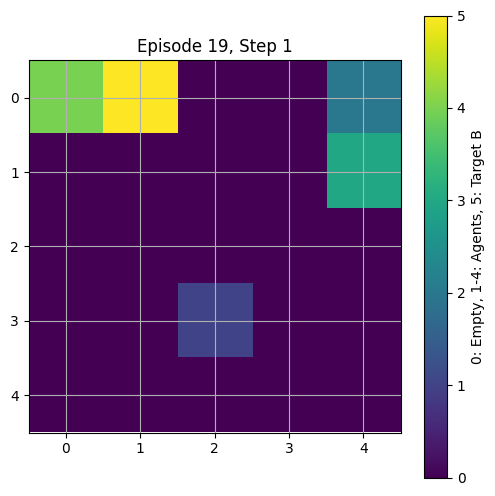

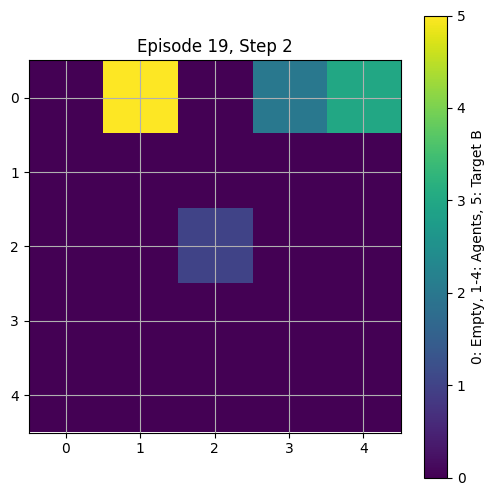

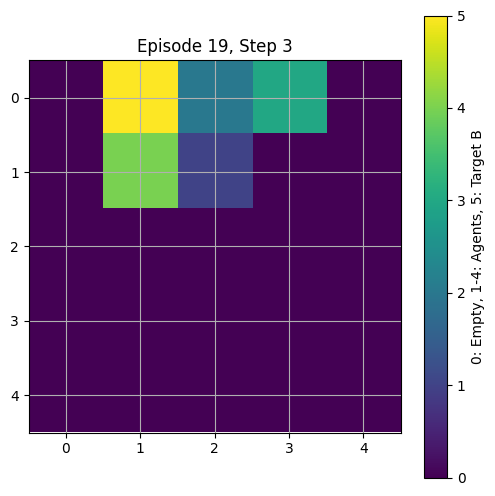

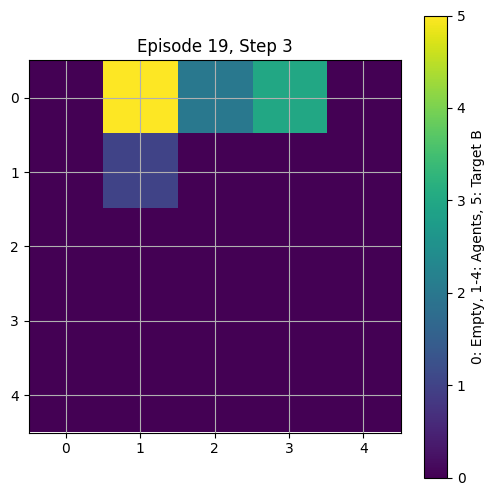

Test Episode 19: Steps Taken = 3, Total Reward = 120


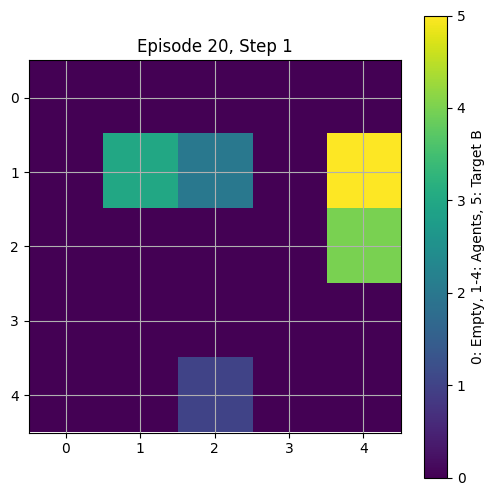

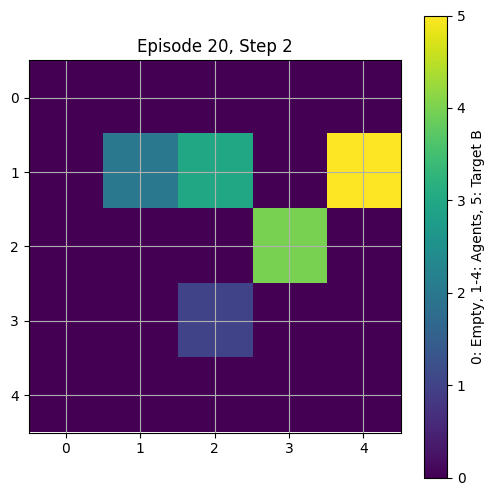

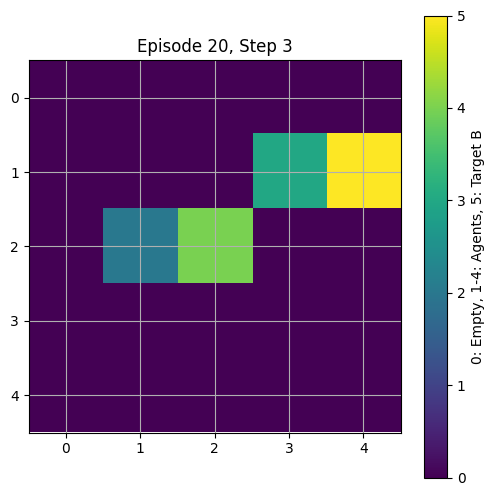

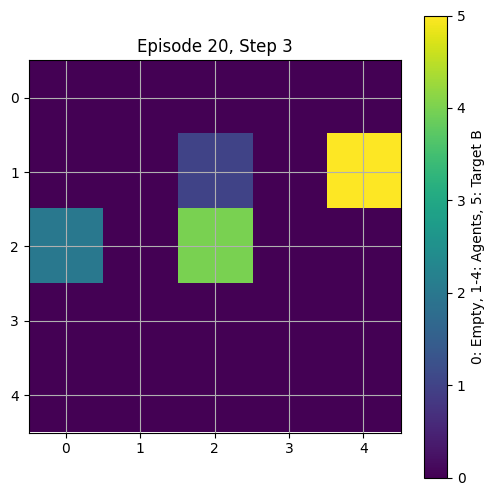

Test Episode 20: Steps Taken = 3, Total Reward = 135


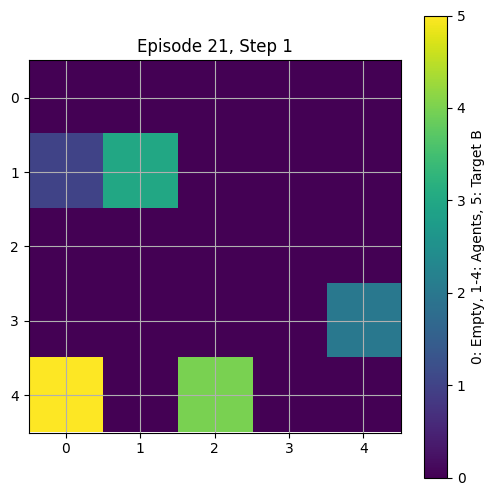

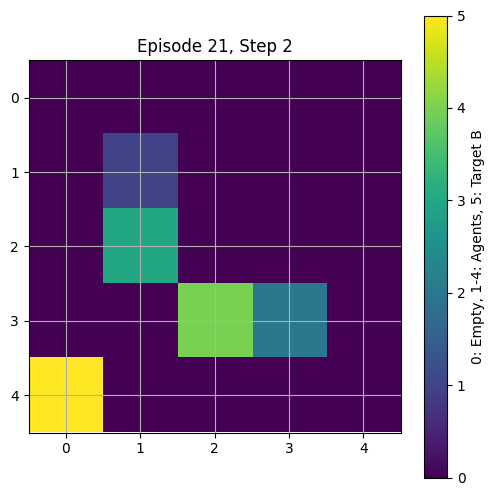

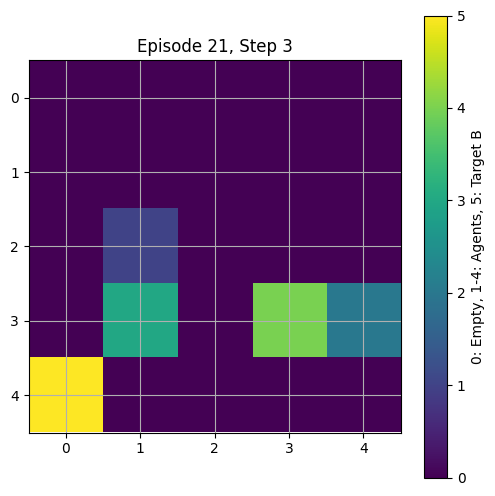

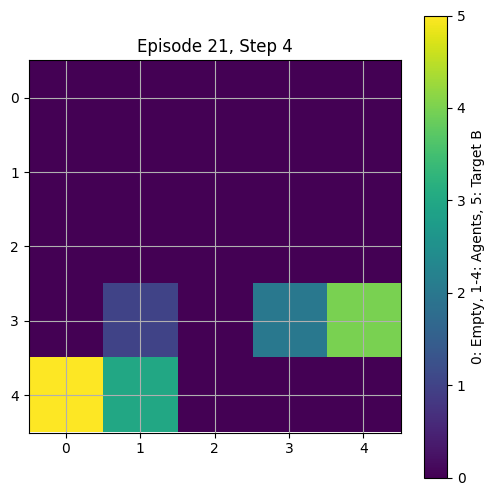

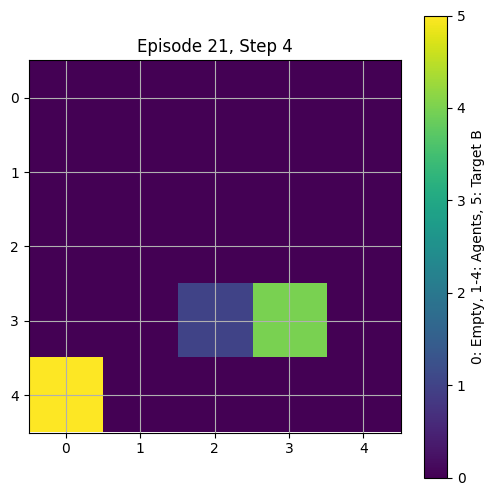

Test Episode 21: Steps Taken = 4, Total Reward = 115


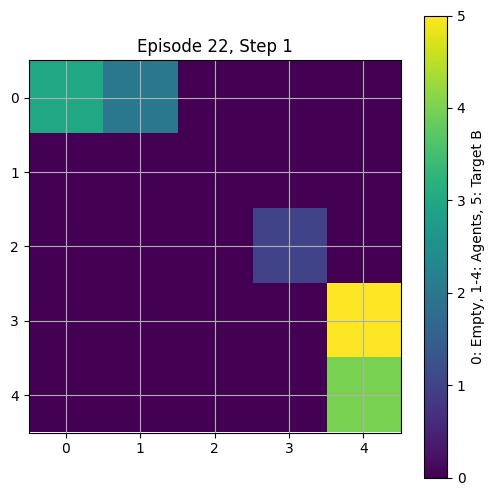

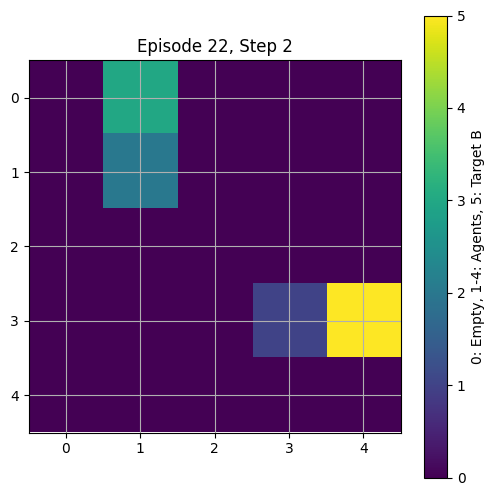

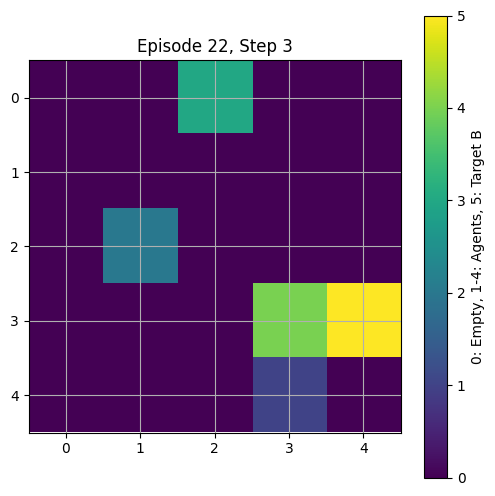

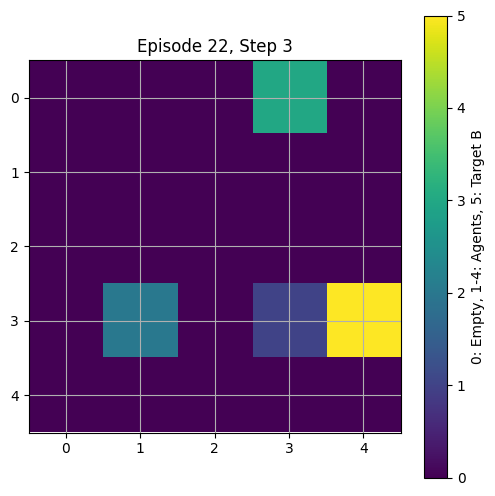

Test Episode 22: Steps Taken = 3, Total Reward = 130


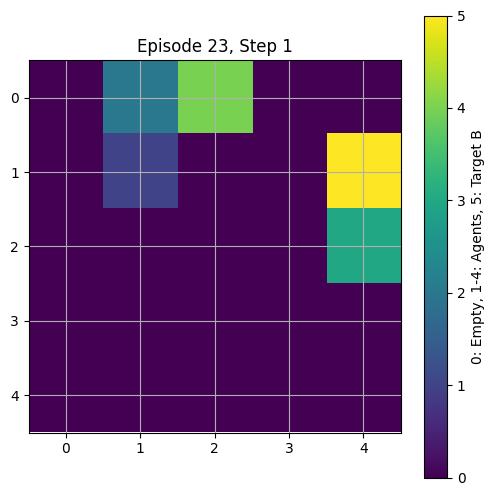

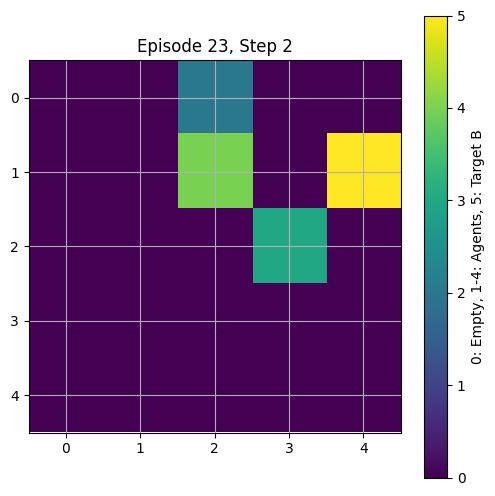

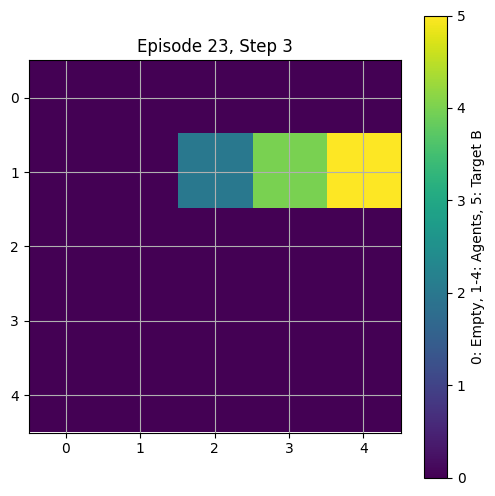

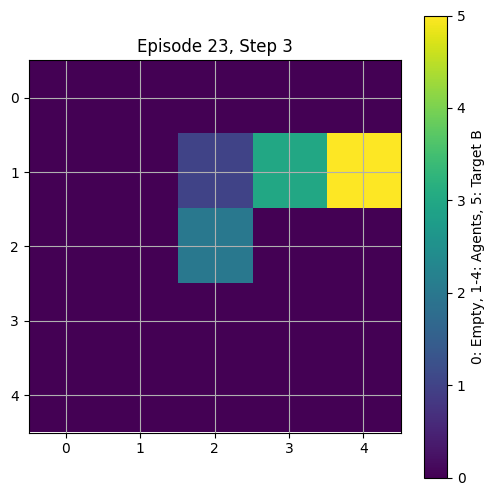

Test Episode 23: Steps Taken = 3, Total Reward = 135


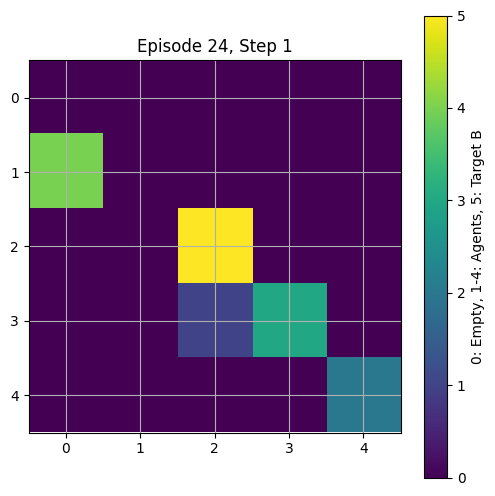

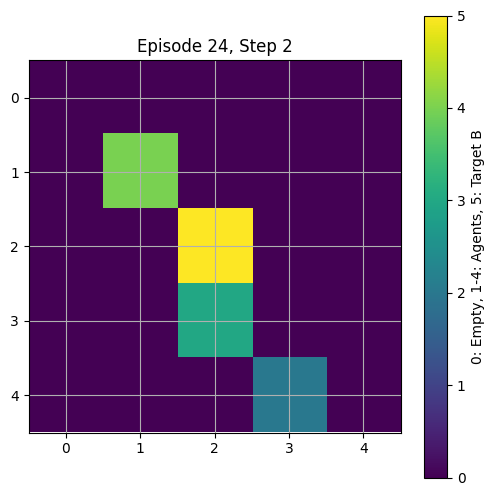

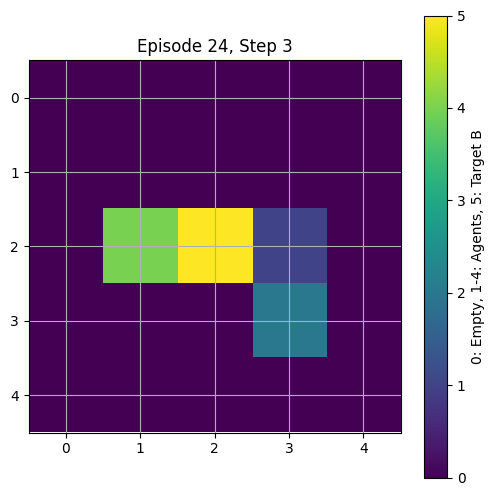

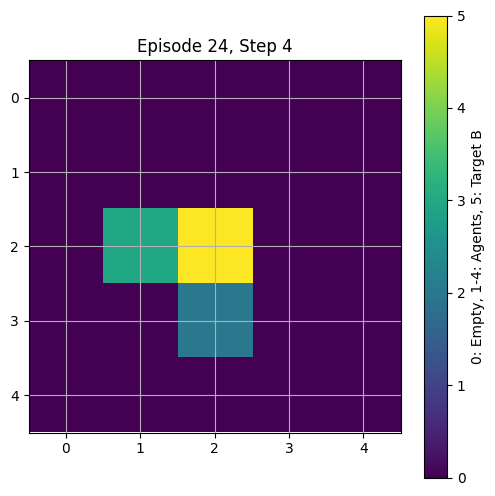

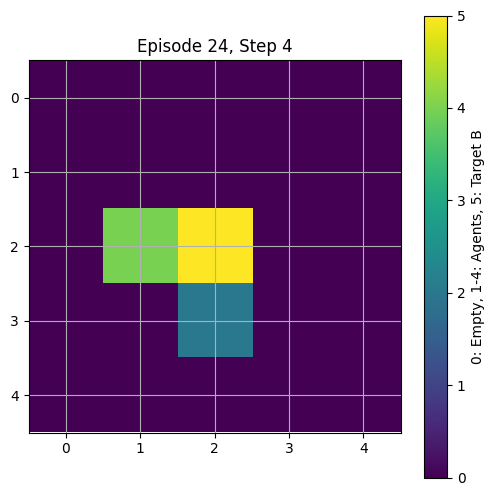

Test Episode 24: Steps Taken = 4, Total Reward = 115


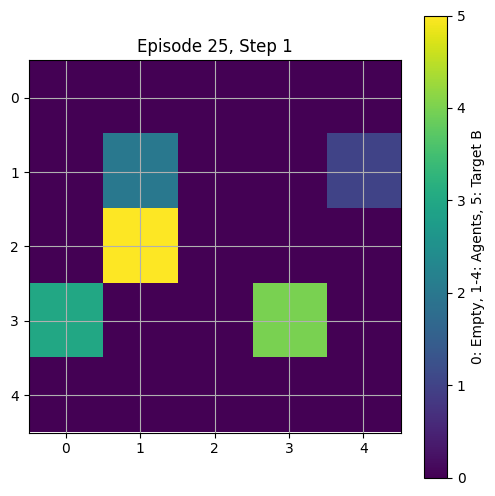

KeyboardInterrupt: 

In [ ]:
test_run = TestRun(deep_q_agents, env_initialise, episodes=100)  # Test the trained agents
test_run.run()                                                   # Run the test episodes using the trained models
